## Bibliothèques

#### librairie "morta_nuts2" 

In [1]:
1

1

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable
import numpy as np

In [3]:
from morta_nuts2.data.eurostat import*
from morta_nuts2.data.mortality_table import*
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis,plot_Bsplines
from morta_nuts2.model.parameters_init.param_init import*
from morta_nuts2.model.projection.project_class import*
from morta_nuts2.model.LC_p.lcp_class import*
from morta_nuts2.model.LL_p.llp_class import*
from morta_nuts2.graph.plot_class import*

### Test fonctions imports de data eurostat

In [4]:
#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "FR")
deaths_fr = data_brute.load("deaths", "FR")
population_fr = data_brute.load("population", "FR")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Loading NUTS shapefile... NUTS_RG_01M_2024_3035.shp
✅ Shapefile loaded (1798 features)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [23]:
#data_fr = data_brute.load_all("FR")

### Test function for data create

In [6]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr,gender="T")

2026-03-24 09:46:20,152 - MortalityCalculator - INFO - Loading shapefile: c:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\NUTS_files\NUTS_RG_01M_2024_3035.shp
2026-03-24 09:46:20,438 - MortalityCalculator - INFO - 1793 regions loaded
2026-03-24 09:46:20,453 - MortalityCalculator - INFO - MortalityCalculator initialized with 1793 regions
2026-03-24 09:46:20,455 - MortalityCalculator - INFO - Validating input data...
2026-03-24 09:46:23,855 - MortalityCalculator - INFO - Validation successful
2026-03-24 09:46:23,858 - root - INFO - validate_input_data executed in 3.40 seconds
2026-03-24 09:46:23,877 - MortalityCalculator - INFO - Result retrieved from cache
2026-03-24 09:46:23,879 - root - INFO - calculate_mortality executed in 3.42 seconds


In [7]:
table = table[table['year'] != 2024]

#### Paramètres

In [8]:
Muxtg,Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)
degree = 3
n_knots = 25
nb_iter = 5000
lam = 0
Dxt = np.sum(Dxtg, axis=2)
Ext = np.sum(Extg, axis=2)
path_fr ="C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/FR"


Shape Dxtg : (83, 34, 22)
Shape Extg : (83, 34, 22)
Shape Muxtg : (83, 34, 22)
Ages : 83
Years : 34
Regions : 22


#### modèle Lee carter 

###### modèle Lee carter non paramétrique

In [10]:
#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))

In [11]:
model_classic = LeeCarter.Classic(nb_iter=nb_iter, eta=1)

results_lc_classic = model_classic.fit(
    ax     = ax_init,
    bx     = bx_init,
    kappa  = kappa_init,
    Extg   = Extg,
    Dxtg   = Dxtg,
    xv     = xv,
    tv     = tv,
)

In [12]:
results_lc_classic['fit_statistics']

,N,m,degree,dofs,lnL,AIC,BIC
0,62084,NA,NA,200,-282530.49,565460.97,567268.22


###### modèle Lee carter paramétrique

In [13]:
_, _, n_basis = make_bspline_basis(
    xv, degree, n_knots)

In [14]:
ax_coef_init, bx_coef_init, kappa_init = lcp_parametrique_init_national(
    Dxtg, Extg, xv, tv, n_basis=n_basis, degree=degree, n_knots=n_knots
)


In [15]:
# 
model_nat = LeeCarter.Parametric.National(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=nb_iter,
    eta0=0.2,
    tol=1e-4,
    verbose=True,
)

results_lcp_nat = model_nat.fit(
    ax_coef_init  = ax_coef_init,
    bx_coef_init  = bx_coef_init,
    kappa_init    = kappa_init,
    Extg          = Extg,
    Dxtg          = Dxtg,
    xv            = xv,
    tv            = tv,)

It    0 | lnL = -284711.5040 | Δ = +inf | η = 0.20000
It   10 | lnL = -283007.8538 | Δ = +6.259881 | η = 0.32578
It   20 | lnL = -282992.7944 | Δ = +0.588005 | η = 0.53066
It   30 | lnL = -282989.7950 | Δ = +0.142542 | η = 0.86439
It   40 | lnL = -282989.1866 | Δ = +0.020523 | η = 1.40800
It   50 | lnL = -282989.1285 | Δ = +0.000000 | η = 1.00000

Convergence reached (tolerance) at it 50.

FINAL STATISTICS
    N  n_basis  dofs        lnL      deviance       AIC       BIC
62084       27  88.0 -282989.13 -1.103963e+08 566154.26 566949.45


#### Modèle Lee and Li

###### modèle Lee and Li non paramétrique

In [16]:
#------------------------------------------------------------------------------
bx_gr_init    =   0.0000010*np.ones((len(xv),len(regions)))
kappa_gr_init =   0.0000010*np.ones((len(tv),len(regions)))


In [17]:
model_c = LiLee.Classic(nb_iter=nb_iter,
                         verbose=False)

result_ll = model_c.fit(
    ax       = ax_init,
    bx       = bx_init,
    bx_gr    = bx_gr_init,
    kappa    = kappa_init,
    kappa_gr = kappa_gr_init,
    Extg     = Extg,
    Dxtg     = Dxtg,
    Muxtg    = Muxtg,
    xv       = xv,
    tv       = tv,
)

###### modèle Lee and Li avec Bsplines paramétrique

In [18]:
model_p = LiLee.Parametric.FullModel(
    degree=degree,
    n_knots=n_knots,
    lam=lam,
    nb_iter=10000,
    eta0=0.2,
    tol=1e-3,
    verbose=True,
)

init = model_p.init_params(Dxtg, Extg, xv )

In [19]:
result_llp = model_p.fit(*init, Extg, Dxtg, xv, tv)

PARAMETRIC LI-LEE MODEL CALIBRATION
Parameters: degree=3, n_knots=25, lam=0
Data: 83 ages × 34 years × 22 regions
Number of basis functions: 27
It    0 | lnL = -402,788.96 | Δ = -402788.956548 | η = 0.10000
It   10 | lnL = -220,339.53 | Δ = +1665.992113 | η = 0.07757
It   20 | lnL = -214,227.29 | Δ = +237.086240 | η = 0.12635
It   30 | lnL = -212,977.77 | Δ = +79.024563 | η = 0.20581
It   40 | lnL = -212,233.41 | Δ = +81.909693 | η = 0.33524
It   50 | lnL = -211,273.01 | Δ = +96.004251 | η = 0.54607
It   60 | lnL = -210,709.16 | Δ = +28.144994 | η = 0.88949
It   70 | lnL = -210,526.58 | Δ = -13.874693 | η = 1.44888
It   80 | lnL = -210,454.43 | Δ = +1.586698 | η = 0.12135
It   90 | lnL = -210,437.64 | Δ = +1.938440 | η = 0.19767
It  100 | lnL = -210,413.57 | Δ = +2.831353 | η = 0.32198
It  110 | lnL = -210,379.22 | Δ = +3.955078 | η = 0.52448
It  120 | lnL = -210,332.95 | Δ = +5.176528 | η = 0.85432
It  130 | lnL = -210,274.97 | Δ = +6.266172 | η = 1.39159
It  140 | lnL = -210,558.33 |

In [37]:
# kappa_g = result_llp['parameters']["kappa_g"]
# mask    = ~np.isin(tv, [2020, 2021])

# print("Drift kappa_g par région après fit :")
# for g, name in enumerate(regions):
#     drift = np.diff(kappa_g[ g,mask]).mean()
#     sens  = "↓ OK" if drift < 0 else "↑ PROBLÈME"
#     print(f"  {name}: {drift:.4f}  {sens}")

In [34]:
import pandas as pd

models = {
    "LC": results_lc_classic,
    "LC parametric": results_lcp_nat,
    "Li-Lee": result_ll,
    "Li-Lee parametric": result_llp,
}

rows = []

for name, result in models.items():
    stats = result['fit_statistics'].iloc[0]
    
    rows.append({
        "Model": name,
        "N": stats["N"],
        "dofs": stats["dofs"],
        "lnL": stats["lnL"],
        "AIC": stats["AIC"],
        "BIC": stats["BIC"]
    })

comparison_table = pd.DataFrame(rows)


#comparison_table.to_csv(path_fr + "/models.csv", index=False)

##### MAE & WMAE

In [35]:
mae_ll = compute_mae(Muxtg, result_ll['fitted_values']['mu'], weights=Extg)
mae_llp = compute_mae(Muxtg, result_llp['fitted_values']['mu'], weights=Extg)
mae_lcp = compute_mae(Muxtg, results_lcp_nat['fitted_values']['mu'], weights=Extg)

print(f"MAE  global — LC : {mae_ll['global']:.6f} | LL : {mae_llp['global']:.6f}")
print(f"WMAE global — LC : {mae_ll['wmae_global']:.6f} | LL : {mae_llp['wmae_global']:.6f}")

MAE  global — LC : 0.000459 | LL : 0.000429
WMAE global — LC : 0.000294 | LL : 0.000266


C:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\src\morta_nuts2\graph\plot_class.py:698: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


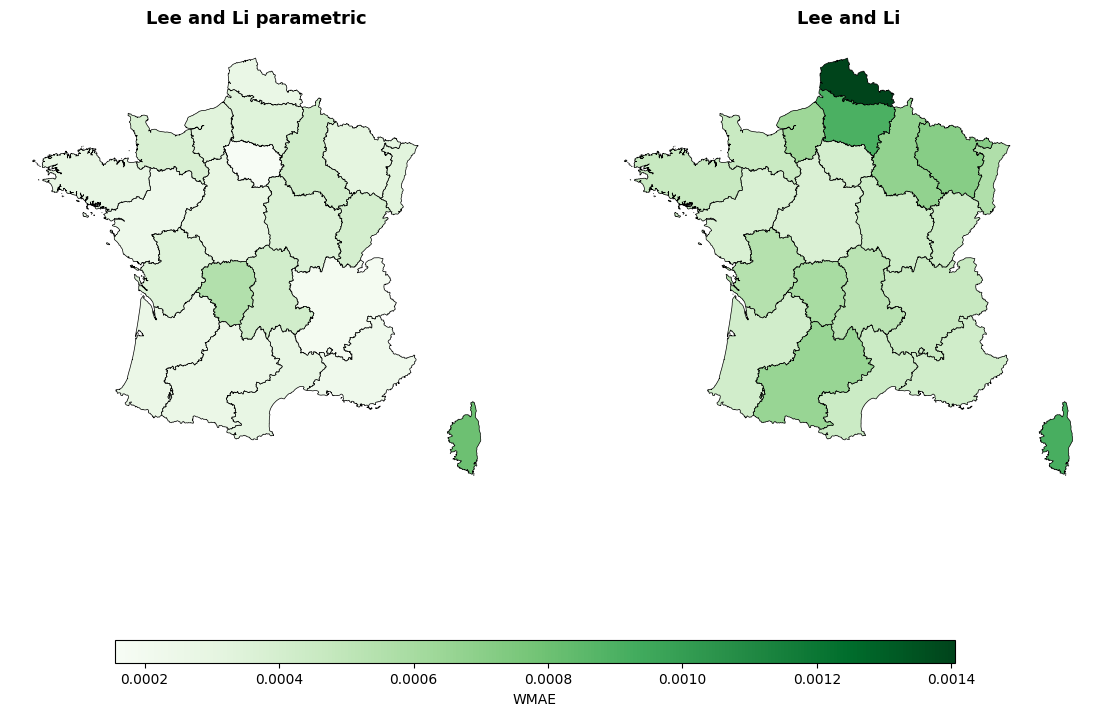

✅ Saved → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/output_note/FR/WMAE_llp_vs_lc_color_detra.png


In [36]:
tv_future = np.arange(1990, 2024) #années
mp = MapPlotter(regions, mae_llp['wmae_by_region'], tv_future, "FR", "WMAE",cmap="Greens")
#mp.plot_static(mae_llp['wmae_by_region'])
mp.plot_compare_models(
    other_data=mae_lcp['wmae_by_region'],
    model_labels=("Lee and Li parametric", "Lee and Li"),
    static=True,
    cmap_diverging="Greens",   # diverging pour erreurs signées
)
mp.save(path_fr +"/WMAE_llp_vs_lc_color_detra.png")

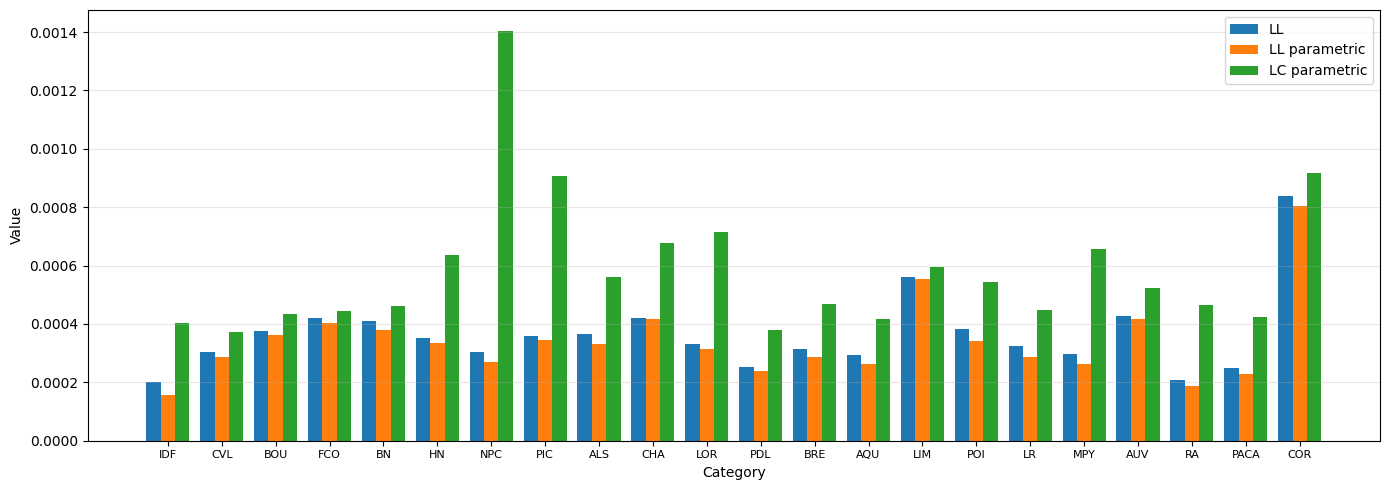

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# --- Tes arrays de MAE par modèle ---
mae = {
    "LL":  mae_ll['wmae_by_region'] ,  # ton array
    "LL parametric":      mae_llp['wmae_by_region'],
     "LC parametric": mae_lcp["wmae_by_region"] }
    
# -------- abbreviation of NUTS 2 regions --------
# Bel_nuts2 = {
#     "BE10": "BXL",
#     "BE21": "ANT",
#     "BE22": "LIM",
#     "BE23": "OVL",
#     "BE24": "VlB",
#     "BE25": "WVl",
#     "BE31": "BWA",
#     "BE32": "HAI",
#     "BE33": "LIE",
#     "BE34": "LUX",
#     "BE35": "NAM"
# }


France_nuts2 = {
    "FR10": "IDF", "FRB0": "CVL", "FRC1": "BOU", "FRC2": "FCO",
    "FRD1": "BN",  "FRD2": "HN",  "FRE1": "NPC", "FRE2": "PIC",
    "FRF1": "ALS", "FRF2": "CHA", "FRF3": "LOR", "FRG0": "PDL",
    "FRH0": "BRE", "FRI1": "AQU", "FRI2": "LIM", "FRI3": "POI",
    "FRJ1": "LR",  "FRJ2": "MPY", "FRK1": "AUV", "FRK2": "RA",
    "FRL0": "PACA","FRM0": "COR"
}
region_labels = list(France_nuts2.values())

models  = list(mae.keys())
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # bleu, orange, vert, rouge
n       = len(region_labels)
n_models = len(models)
width   = 0.8 / n_models  # barres qui se touchent presque
x       = np.arange(n)

fig, ax = plt.subplots(figsize=(14, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, mae[model], width, label=model, color=color)

ax.set_xticks(x)
ax.set_xticklabels(region_labels, rotation=0, fontsize=8)
ax.set_xlabel("Category")
ax.set_ylabel("Value")
ax.legend()
ax.grid(axis="y", alpha=0.3)
#ax.set_title("Histogram of weighted mean absolute errors by regions, France.")
#plt.savefig(path_fr + "/Histogram_wmae.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd

# DataFrame avec régions en index
df_wmae = pd.DataFrame(mae, index=region_labels)

# Affichage
df_wmae

,LL,LL parametric,LC parametric
IDF,0.000201,0.000156,0.000404
CVL,0.000304,0.000288,0.000372
BOU,0.000377,0.000363,0.000434
FCO,0.000421,0.000402,0.000446
BN,0.000410,0.000378,0.000461
HN,0.000353,0.000335,0.000637
NPC,0.000303,0.000269,0.001406
PIC,0.000358,0.000344,0.000905
ALS,0.000367,0.000331,0.000561
CHA,0.000420,0.000416,0.000677


In [39]:
df_final = df_wmae.copy()

df_final["LLp vs LL (%)"] = (df_wmae["LL parametric"] - df_wmae["LL"]) / df_wmae["LL"] * 100
df_final["LCp vs LL (%)"] = (df_wmae["LC parametric"] - df_wmae["LL"]) / df_wmae["LL"] * 100
df_final["LLp vs LCp (%)"] = (df_wmae["LL parametric"] - df_wmae["LC parametric"]) / df_wmae["LC parametric"] * 100


df_final.head()
#df_final.to_csv(path_fr + "/wmae.csv", index=False)

,LL,LL parametric,LC parametric,LLp vs LL (%),LCp vs LL (%),LLp vs LCp (%)
IDF,0.000201,0.000156,0.000404,-22.625123,100.545027,-61.417704
CVL,0.000304,0.000288,0.000372,-5.385100,22.323840,-22.652117
BOU,0.000377,0.000363,0.000434,-3.681576,15.050288,-16.281458
FCO,0.000421,0.000402,0.000446,-4.499609,5.956236,-9.868079
BN,0.000410,0.000378,0.000461,-7.643449,12.559974,-17.949029


C:\Users\Idrissa Belem\AppData\Local\Temp\ipykernel_16732\3867936858.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", n_regions)


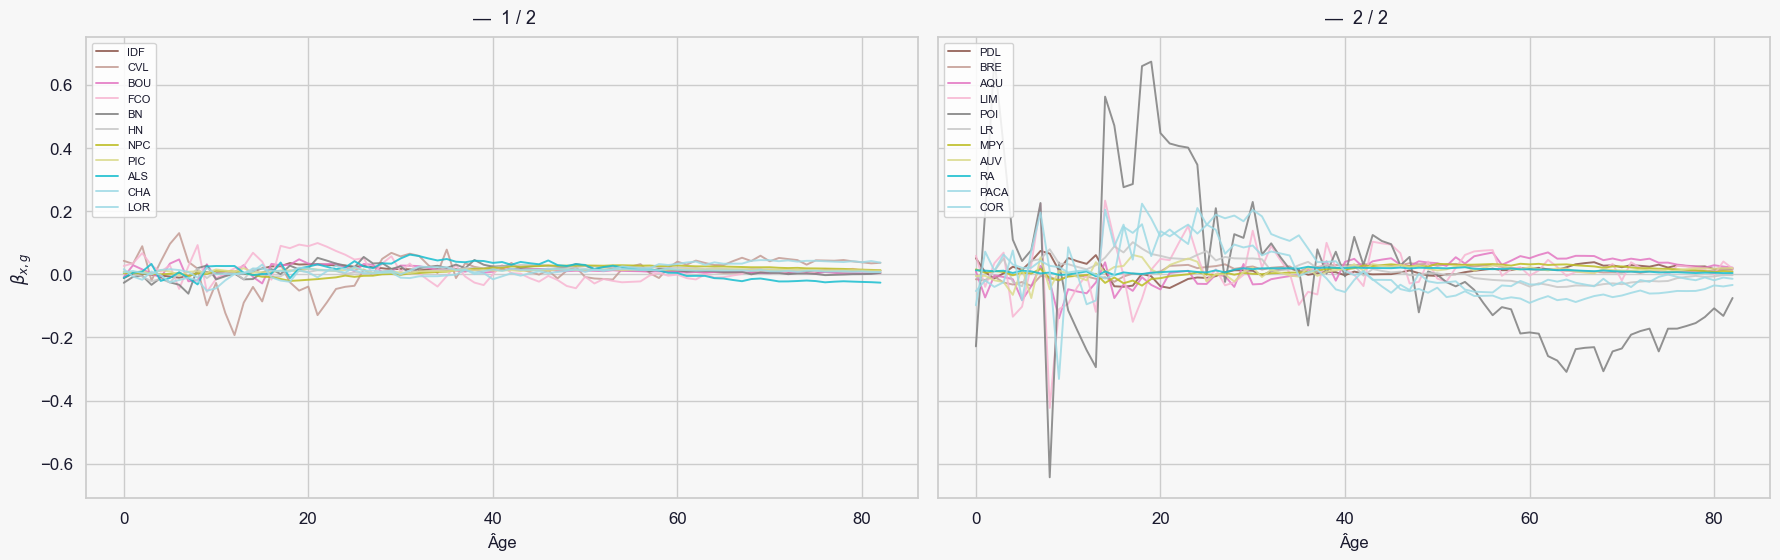

✅ Graphe sauvegardé : regional_curves.png


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# CONFIG — adapte ces valeurs à ton projet
# ─────────────────────────────────────────────
CURVE_KEY   = "beta_xg"          # clé dans result_llp["curves"]
COMPARE_KEY = None                # ex: "beta_xg" dans result_ref, ou None

STYLE = "whitegrid"               # "dark", "whitegrid", "white"

# ─────────────────────────────────────────────
  # ← remplace par ta vraie courbe

# ─────────────────────────────────────────────
# Fonction principale
# ─────────────────────────────────────────────
def plot_regional_curves(
    xv,
    curves,           # shape (n_ages, n_regions)
    region_labels,
    compare_curve=None,
    compare_label="Référence",
    curve_key=r"$\beta_{x,g}$",
    title_prefix="Courbes régionales",
    style="whitegrid",
):
    import seaborn as sns
    sns.set_theme(style=style, font_scale=1.1)

    n_regions = len(region_labels)
    mid = n_regions // 2
    splits = [
        (region_labels[:mid],  curves[:, :mid],  " 1 / 2"),
        (region_labels[mid:],  curves[:, mid:],  " 2 / 2"),
    ]

    # Palette continue sur tout le set de régions
    palette = cm.get_cmap("tab20", n_regions)
    colors  = [palette(i) for i in range(n_regions)]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 6),
        sharey=True,
        facecolor="#F7F7F7" if style != "dark" else "#1C1C2E",
    )
    fig.subplots_adjust(wspace=0.08)

    bg_color  = "#F7F7F7" if style != "dark" else "#1C1C2E"
    txt_color = "#1a1a2e"  if style != "dark" else "#E0E0E0"

    for ax, (labels, sub_curves, subtitle) in zip(axes, splits):
        ax.set_facecolor(bg_color)
        start_idx = 0 if labels is region_labels[:mid] else mid

        for j, region in enumerate(labels):
            global_idx = start_idx + j
            ax.plot(
                xv, sub_curves[:, j],
                color=colors[global_idx],
                linewidth=1.4,
                alpha=0.85,
                label=region,
            )

        # Courbe de référence
        if compare_curve is not None:
            ax.plot(
                xv, compare_curve,
                color="#E63946",
                linewidth=2.2,
                linestyle="--",
                alpha=0.95,
                label=compare_label,
                zorder=10,
            )

        ax.set_xlabel("Âge", color=txt_color, fontsize=12)
        ax.set_title(f"{title_prefix} — {subtitle}", color=txt_color, fontsize=13, pad=10)
        ax.tick_params(colors=txt_color)
        for spine in ax.spines.values():
            spine.set_edgecolor("#CCCCCC" if style != "dark" else "#444")

        legend = ax.legend(
            fontsize=8,
            framealpha=0.85,
            loc="upper left",
            ncol=1,
        )
        for text in legend.get_texts():
            text.set_color(txt_color)

    axes[0].set_ylabel(curve_key, color=txt_color, fontsize=12)

    # Titre global
    fig.suptitle(
        title_prefix,
        fontsize=16,
        fontweight="bold",
        color=txt_color,
        y=1.02,
    )

    # # Légende partagée pour la courbe de référence (si présente)
    # if compare_curve is not None:
    #     ref_handle = Line2D([0], [0], color="#E63946", linewidth=2.2, linestyle="--")
    #     fig.legend(
    #         handles=[ref_handle],
    #         labels=[compare_label],
    #         loc="lower center",
    #         ncol=1,
    #         fontsize=10,
    #         framealpha=0.9,
    #         bbox_to_anchor=(0.5, -0.06),
    #     )

    plt.tight_layout()
    #plt.savefig(path_fr + "/regional_beta_LL.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Graphe sauvegardé : regional_curves.png")


# ─────────────────────────────────────────────
# Appel
# ─────────────────────────────────────────────
plot_regional_curves(
    xv            = xv,
    curves        = result_ll["parameters"]["bx_gr"],
    region_labels = region_labels,
    compare_curve = None , #results_lc_classic['parameters']["bx_coef"],
    compare_label = 'LC',
    curve_key     = r"$\beta_{x,g}$",
    title_prefix  = '',
    style         = STYLE,
)

##### Graph

In [41]:
mu_obs = Dxtg / Extg
mu_nat = results_lcp_nat["fitted_values"]["mu"]  # (83, 34)

mu_nat_rep = np.repeat(mu_nat[:, :, None], 22, axis=2)
curves = {
    "Observed": mu_obs,
    "LL": result_ll['fitted_values']['mu'],
    "LL parametric": result_llp["fitted_values"]["mu"],
    "LC parametric": mu_nat_rep }


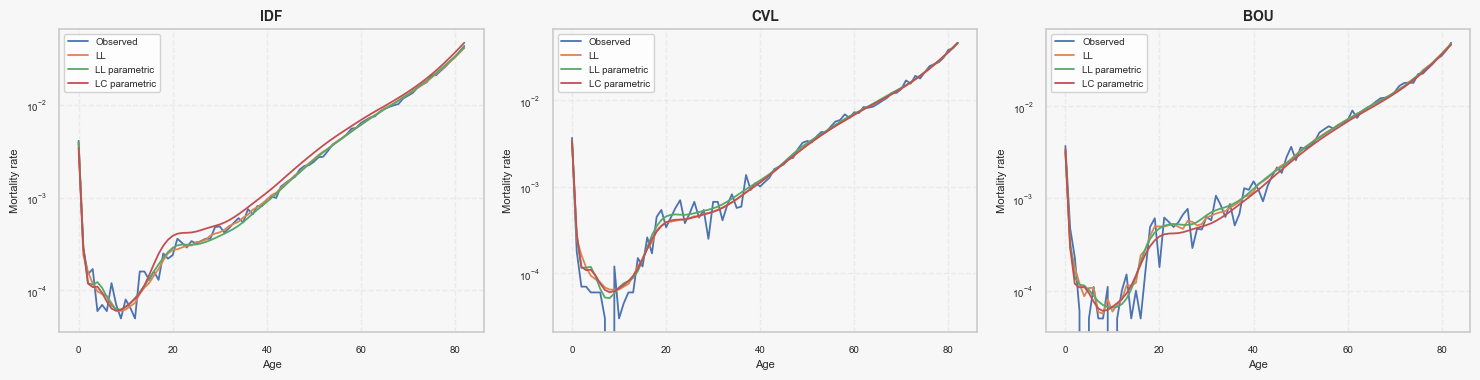

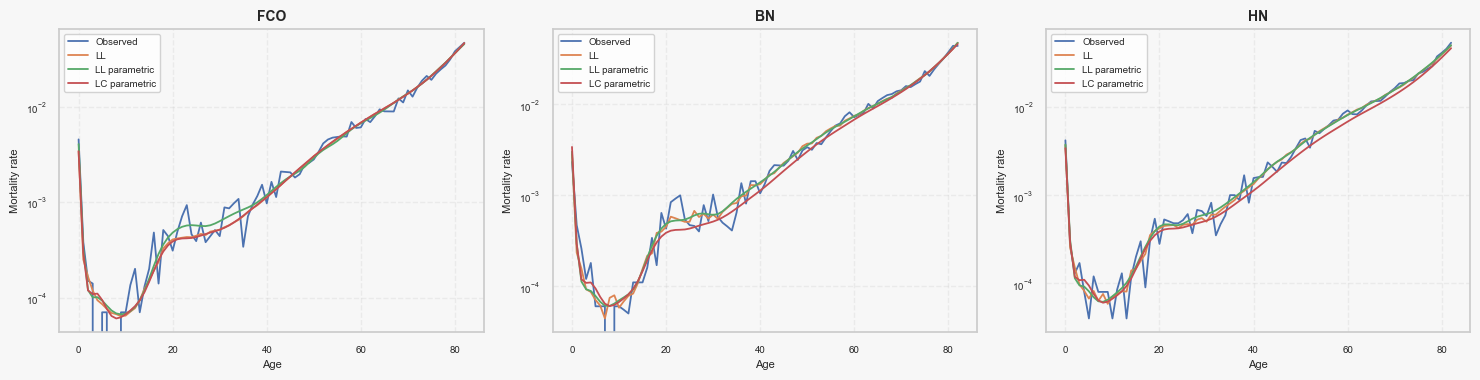

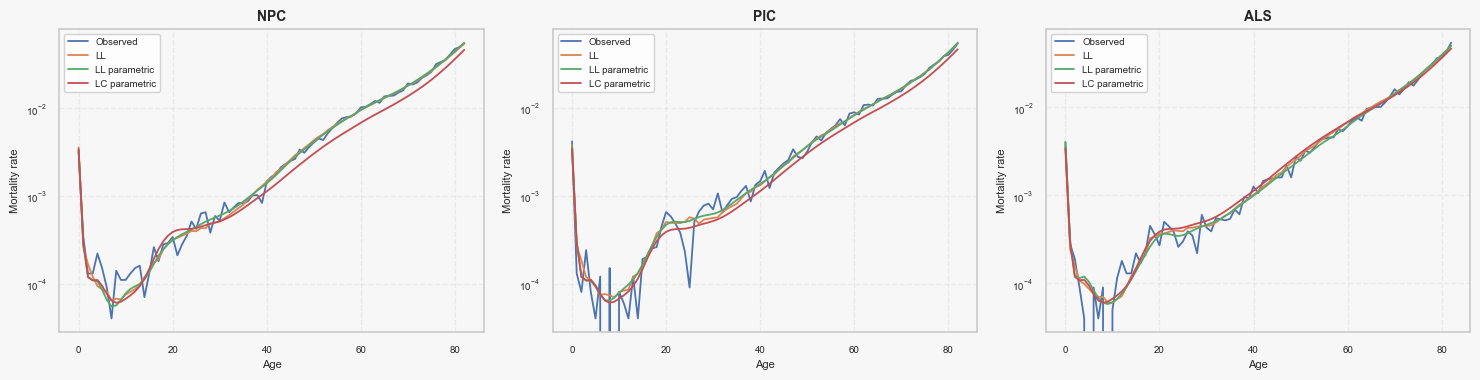

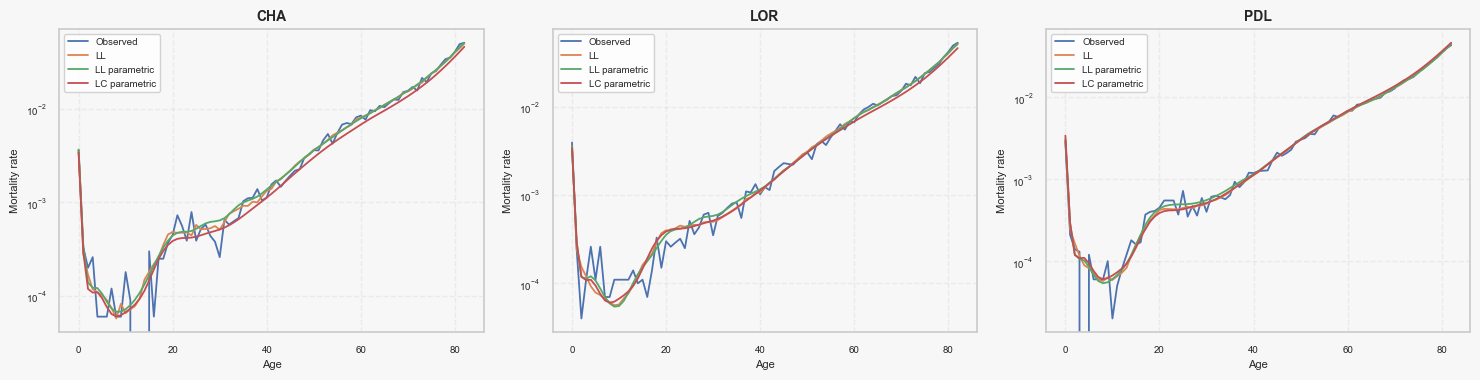

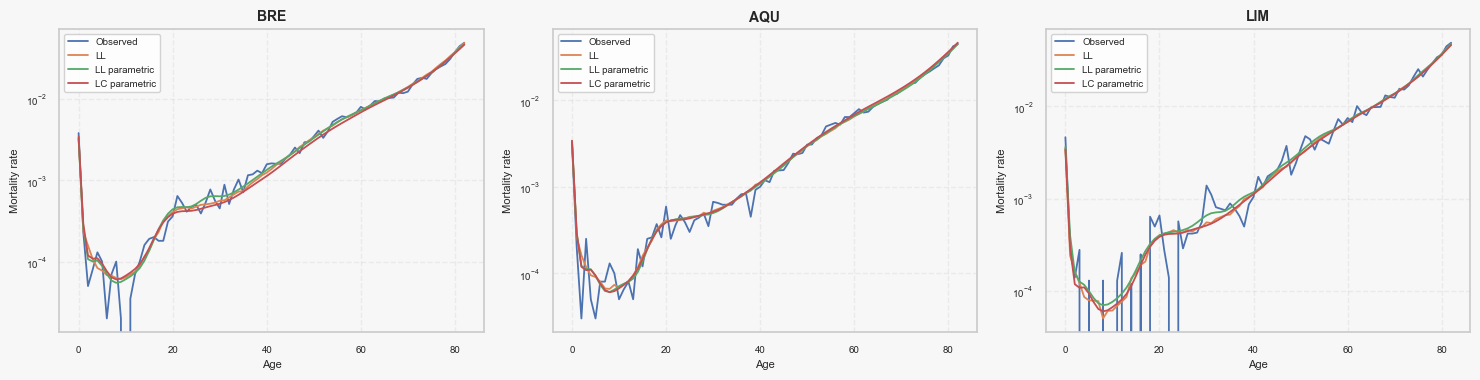

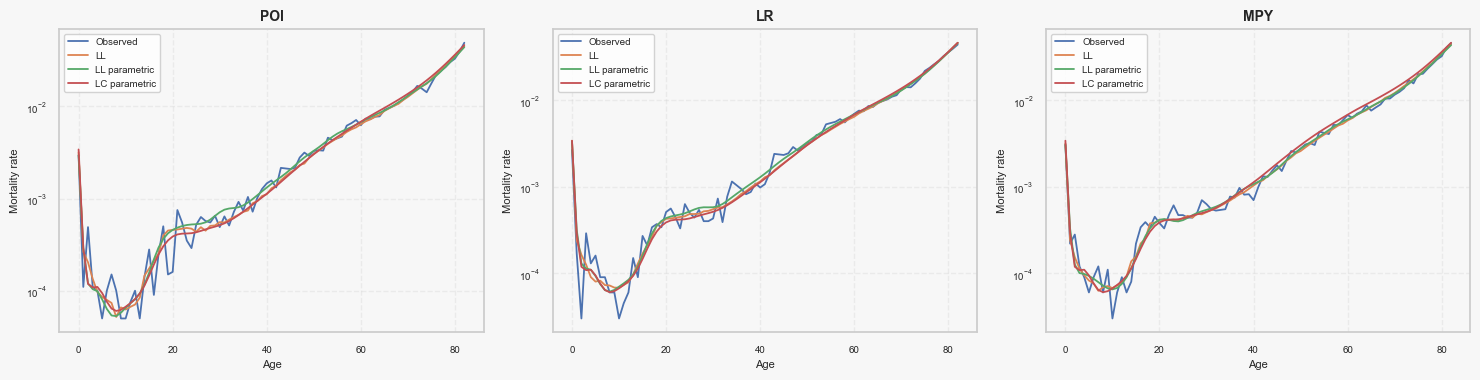

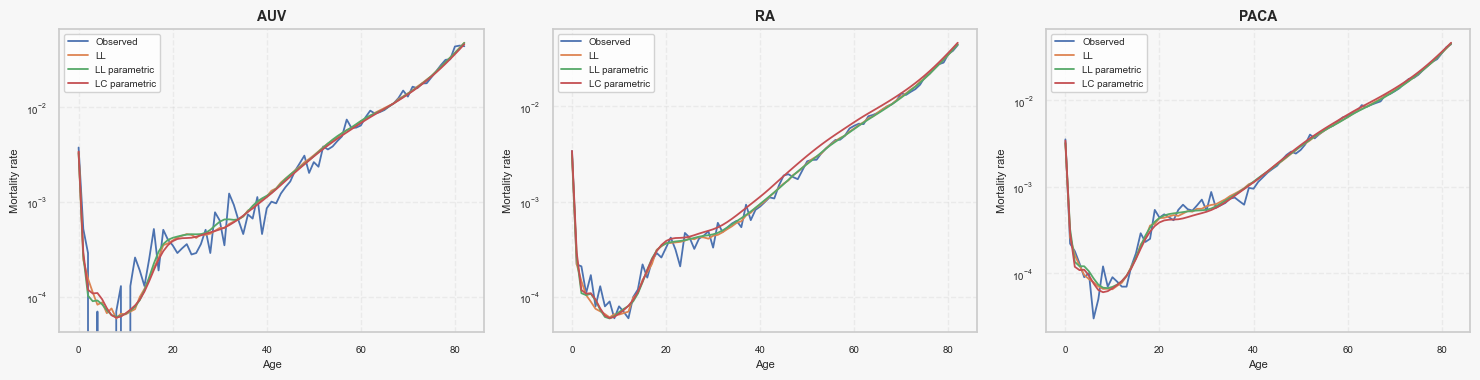

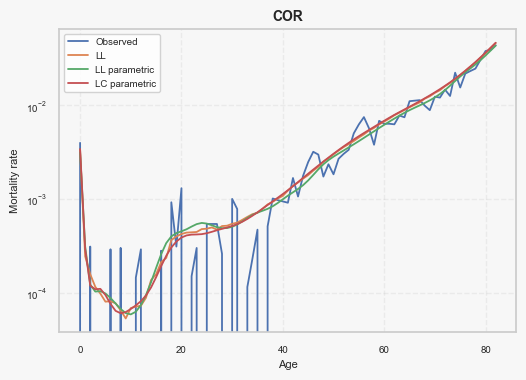

In [42]:
# ── RegionalCurvePlotter ────────────────────────────────────────────
plotter = RegionalCurvePlotter(
    x_values=xv,
    curves_dict=curves,
    tv=tv,
    regions=region_labels,
)
plotter.plot(year_to_plot=2015)
#plotter.save(path_fr+ "/mortality_v2_2015.png")

### Projector

###### Lee Carter and Lee and Li

In [43]:
n_sim = 2000
horizon = 50
covid_years = ['2019','2020',"2021"]

In [44]:
proj_lcp_stoch = ProjectorLC_SVD(
    results_lcp_nat, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
    nb_components=2
    ).project()

###### Lee and Li parametric & classic

In [45]:
proj_llp_stoch = ProjectorLeeLi(
    result_llp, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
    nb_components=2
).project()

In [46]:
proj_ll_stoch = ProjectorLeeLi(
    result_ll, tv,
    horizon=horizon,
    model="rw",
    exclude_years=covid_years,
    stochastic=False,
    n_sim=n_sim,
    nb_components=2
).project()

In [47]:
# kappa = result_llp["parameters"]["kappa"]
# kappa_g = result_llp["parameters"]["kappa_g"]  # (nb_regions, T)

# var_kappa = np.var(kappa)
# var_kappa_g = np.var(kappa_g)

# print("Var kappa (commun):", var_kappa)
# print("Var kappa_g (regional):", var_kappa_g)

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# 3b. Plot kappa_g (historical + projected) by region
# ─────────────────────────────────────────────────────────────────────────────

def plot_kappa_g(
    kappa_g_hist: np.ndarray,
    tv: np.ndarray,
    projection: dict,
    horizon: int,
    stochastic: bool = True,
    region_names: list = None,
    exclude_years: list = None,
    regions_per_fig: int = 3,
    save_path: str = None,
    dpi: int = 150,
):
    """
    Plot historical and projected kappa_g by region.
    Generates one figure per group of `regions_per_fig` regions.

    Parameters
    ----------
    kappa_g_hist    : (nb_regions, nb_years)
        Historical kappa_g from the fitted model.
    tv              : array-like
        Observation year vector, length nb_years.
    projection      : dict
        Output of ProjectorLeeLi.project().
    horizon         : int
        Number of projected years.
    stochastic      : bool
        If True, uses median + confidence interval from projection dict.
    region_names    : list, optional
        Labels for each region. Defaults to ["Region 1", "Region 2", ...].
    exclude_years   : list, optional
        Years to mark as excluded (greyed out) on the plot.
    regions_per_fig : int
        Number of regions per figure (= number of subplot columns). Default: 3.
    save_path       : str | Path, optional
        Base path for saving figures. If provided, each figure is saved with
        a "_part{i}" suffix before the extension.
        Example: "output/kappa_g.png"  →  "output/kappa_g_part1.png", ...
        The parent directory is created automatically if it does not exist.
    dpi             : int
        Resolution used when saving (default: 150).

    Returns
    -------
    figs : list of matplotlib Figure
        One figure per group of regions.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from pathlib import Path

    tv            = np.asarray(tv)
    nb_regions    = kappa_g_hist.shape[0]
    tv_proj       = np.arange(tv[-1] + 1, tv[-1] + 1 + horizon)
    exclude_years = exclude_years if exclude_years is not None else []

    if region_names is None:
        region_names = [f"Region {g+1}" for g in range(nb_regions)]

    colors  = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    n_figs  = int(np.ceil(nb_regions / regions_per_fig))
    figs    = []

    for f in range(n_figs):
        g_start = f * regions_per_fig
        g_end   = min(g_start + regions_per_fig, nb_regions)
        group   = list(range(g_start, g_end))
        ncols   = len(group)

        fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 3.5), sharey=False)
        axes = np.array(axes).reshape(-1)

        for pos, g in enumerate(group):
            ax    = axes[pos]
            color = colors[g % len(colors)]
            hist  = kappa_g_hist[g, :]

            # ── historical ──────────────────────────────────────────
            mask_excl = np.isin(tv, exclude_years)
            ax.plot(tv[~mask_excl], hist[~mask_excl], color=color, lw=1.8, label="")
            if mask_excl.any():
                ax.plot(tv[mask_excl], hist[mask_excl], color=color, lw=1.2,
                        linestyle="--", alpha=0.45, label="Années exclues")

            # ── projection ──────────────────────────────────────────
            last_val = hist[-1]

            if stochastic:
                kg_med   = projection["kappa_g_median"]
                kg_lo    = projection["kappa_g_lower"]
                kg_hi    = projection["kappa_g_upper"]

                tv_bridge  = np.concatenate([[tv[-1]],  tv_proj])
                med_bridge = np.concatenate([[last_val], kg_med[:, g]])
                lo_bridge  = np.concatenate([[last_val], kg_lo[:, g]])
                hi_bridge  = np.concatenate([[last_val], kg_hi[:, g]])

                ax.fill_between(tv_bridge, lo_bridge, hi_bridge,
                                color=color, alpha=0.18, label="IC 95%")
                ax.plot(tv_bridge, med_bridge, color=color, lw=1.8,
                        linestyle="--", label="Médiane projetée")
            else:
                kg_fut     = projection["kappa_g_future"]
                tv_bridge  = np.concatenate([[tv[-1]],  tv_proj])
                fut_bridge = np.concatenate([[last_val], kg_fut[:, g]])
                ax.plot(tv_bridge, fut_bridge, color=color, lw=1.8,
                        linestyle="--", label="Projected")

            # ── styling ─────────────────────────────────────────────
            ax.axvline(tv[-1], color="grey", lw=0.8, linestyle=":")
            ax.set_title(region_names[g], fontsize=11)
            ax.set_xlabel("Année")
            ax.set_ylabel(r"$\kappa_t^{(g)}$")
            ax.legend(fontsize=7, loc="best")
            ax.grid(True, alpha=0.3)

        fig.tight_layout()
        figs.append(fig)

        # ── save ────────────────────────────────────────────────────
        # if save_path is not None:
        #     p   = Path(save_path)
        #     p.parent.mkdir(parents=True, exist_ok=True)
        #     out = p.parent / f"{p.stem}_part{f + 1}{p.suffix}"
        #     fig.savefig(out, dpi=dpi, bbox_inches="tight")
        #     print(f"✅ Saved → {out}")

    plt.show()
    return figs

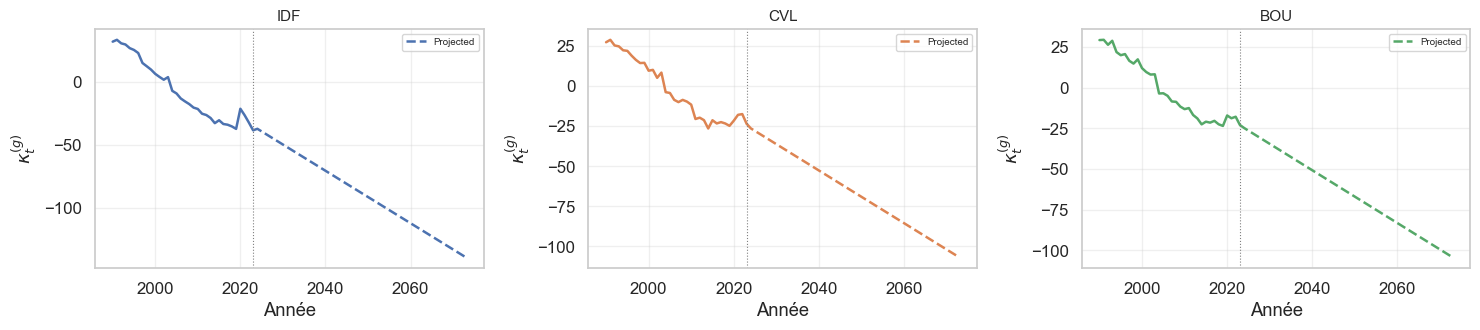

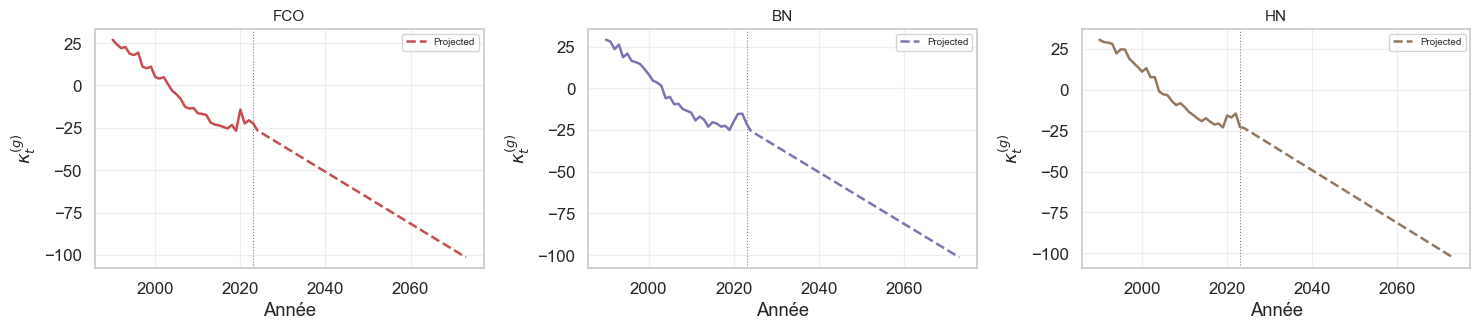

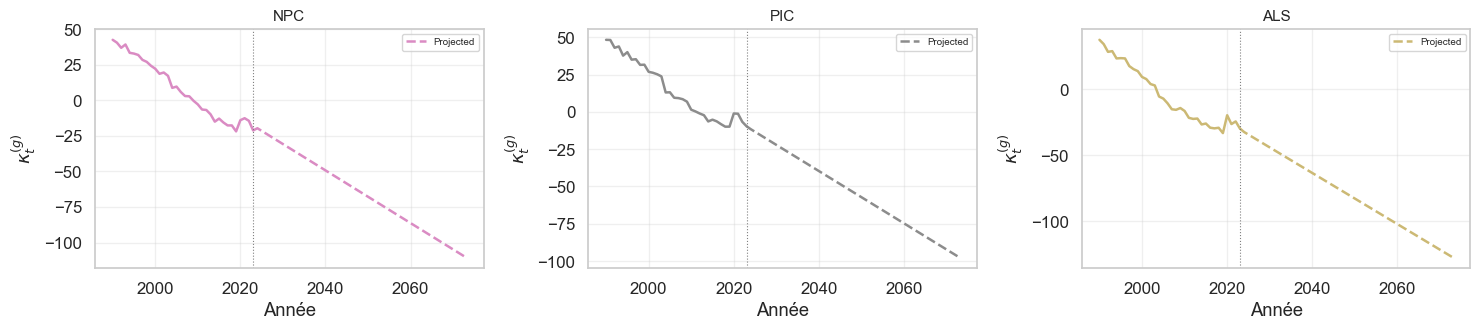

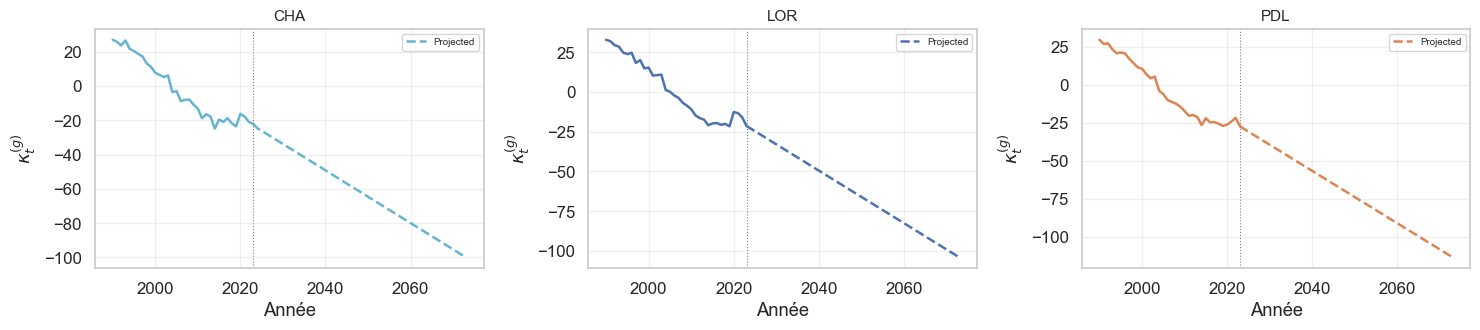

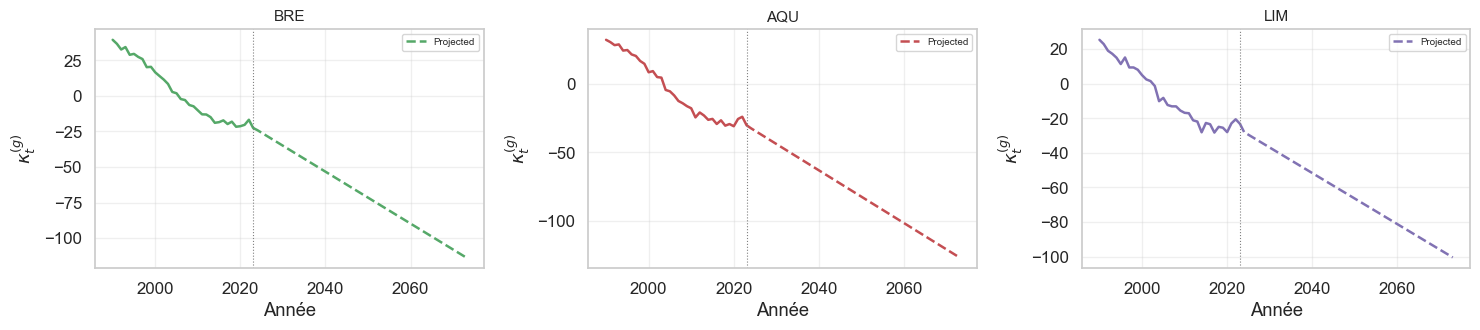

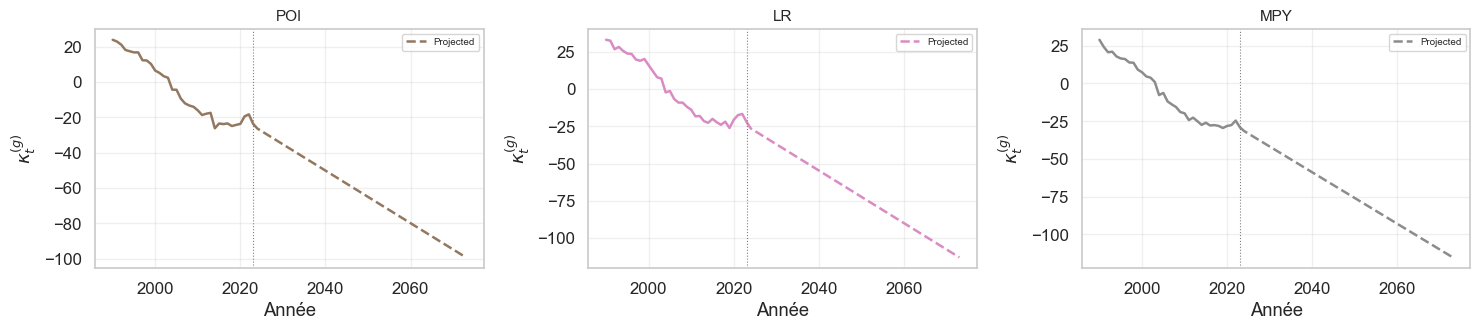

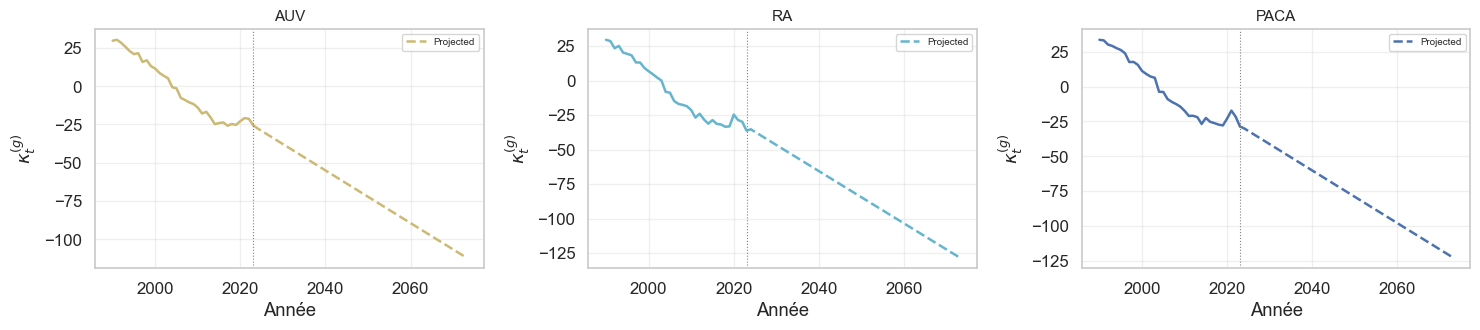

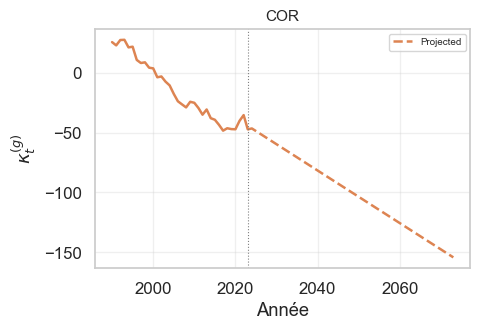

In [50]:
fig = plot_kappa_g(
    kappa_g_hist=result_llp["parameters"]["kappa_g"],  # (nb_regions, T)
    tv=tv,
    projection=proj_llp_stoch,          # dict retourné par .project()
    horizon=50,
    stochastic=False,         # False si projection déterministe
    region_names=region_labels,
    exclude_years=[],
    save_path=path_fr + "/kappa_by_region_project.png"
    )
#fig.savefig("kappa_g.png", bbox_inches="tight")

##### HighAgeExtrapolator

In [51]:
start_age = 60

In [52]:
# logmu_nation_lcp, xv_full = HighAgeExtrapolator(
#     xv          = xv,
#     x_extrap    = 110,          # âge cible
#     x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
#     method="linear",
#     log_Muxtg   = logmu_lc_national, auto_start =False).extrapolate()
    

# # logmu_extrap
# # xv_full      → [0, 1, ..., 110]

# print("log-mu extrapolé :", logmu_nation_lcp.shape)   
# print("Grille d'âges    :", xv_full[[0, -1]]) 

In [53]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
    method="linear",
    log_Muxtg   = proj_llp_stoch["logmu_future"], auto_start =False).extrapolate()
    

# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 50, 22)
Grille d'âges    : [  0 110]


In [54]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_ll, xv_full = HighAgeExtrapolator(
                    xv          = xv,
                    x_extrap    = 110,          # âge cible
                    x_extrap_start = start_age,        # début de la fenêtre de régression
                    method="linear",
                    log_Muxtg   = proj_ll_stoch["logmu_future"],auto_start =False
                ).extrapolate()
# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_ll.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])      

log-mu extrapolé : (111, 50, 22)
Grille d'âges    : [  0 110]


In [55]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_llp_hist, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    method="linear",
    log_Muxtg   = result_llp["fitted_values"]["log_mu"],auto_start =False
).extrapolate()
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [56]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_ll_hist, xv_full = HighAgeExtrapolator(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    method="linear",
    log_Muxtg   = result_ll["fitted_values"]["log_mu"],auto_start =False
).extrapolate()
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_ll_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [57]:
logmu_full_llp = concat_logmu_time(logmu_llp_hist,logmu_extrap_llp)
logmu_full_ll = concat_logmu_time(logmu_ll_hist,logmu_extrap_ll)

In [58]:
print(logmu_full_llp.shape)
print(logmu_full_ll.shape)

(111, 84, 22)
(111, 84, 22)


#### LifeExpectancy

In [59]:
esp_llp = LifeExpectancy(np.exp(logmu_full_llp)).compute()
esp_ll = LifeExpectancy(np.exp(logmu_full_ll)).compute()

In [60]:
esp_llp.shape

(111, 84, 22)

In [61]:
e0_llp = esp_llp[0, :, :]  
e0_ll = esp_ll[0, :, :] 
# shape = (nb_horizon, nb_region)

In [62]:

df_esp_llp = pd.DataFrame(
    e0_llp,
    index=np.arange(1990, 2023 + 51),   # ex: [2023, 2030, 2050]
    columns=region_labels   # ex: ["Ile-de-France", "Occitanie", ...]
)

df_esp_llp.index.name = "horizon"
df_esp_llp.to_csv(path_fr + "/LifeExpectancy_at_birth_ll_parametric.csv", index=False)

In [69]:
df_esp_llp.head(50)

,IDF,CVL,BOU,FCO,BN,HN,NPC,PIC,ALS,CHA,...,BRE,AQU,LIM,POI,LR,MPY,AUV,RA,PACA,COR
horizon,,,,,,,,,,,,,,,,,,,,,
1990,77.551338,77.606037,76.784613,76.727561,76.428900,76.123824,74.120541,75.149659,75.456706,76.225322,...,75.359401,77.150848,76.686565,77.622859,77.100960,77.588793,76.298512,77.262613,77.113966,76.302111
1991,77.406599,77.464604,76.797469,77.103625,76.582307,76.316694,74.402343,75.194603,75.874896,76.403616,...,75.754609,77.373544,77.026863,77.772621,77.197018,78.165679,76.255948,77.400564,77.194041,76.675694
1992,77.715220,77.840553,77.144314,77.346656,77.126199,76.338529,74.821227,75.787131,76.547270,76.630854,...,76.239454,77.606597,77.482985,77.958981,77.834403,78.562050,76.475211,77.994972,77.525285,76.084155
1993,77.788403,77.867864,76.806434,77.232494,76.748307,76.387509,74.496926,75.648032,76.452772,76.244545,...,75.978493,77.508969,77.661484,78.289292,77.620404,78.485915,76.768638,77.760031,77.608825,76.025201
1994,78.066105,78.079323,77.583535,77.668442,77.622415,77.026934,75.146726,76.305451,77.051982,76.776325,...,76.610530,77.964352,77.879675,78.312395,77.868708,78.796982,77.046161,78.269544,77.729381,76.760392
1995,78.226417,78.109605,77.804028,77.753889,77.335283,76.716875,75.201398,76.023893,77.019896,76.920518,...,76.516954,77.910604,78.324597,78.381491,78.054957,78.939177,77.275930,78.376089,77.877137,76.679673
1996,78.458194,78.396774,77.667278,77.524626,77.831037,76.685620,75.264291,76.557404,77.000178,77.067290,...,76.736326,78.225670,77.802063,78.329630,78.039138,78.936713,77.151849,78.446197,78.098838,77.990719
1997,79.300530,78.621781,78.092602,78.490441,77.846959,77.282991,75.613738,76.459522,77.623406,77.180047,...,76.858065,78.287193,78.449311,78.797686,78.389802,79.136563,77.784410,78.987584,78.764275,78.233517
1998,79.553145,78.804560,78.257330,78.584434,77.947921,77.548129,75.739864,76.855821,77.864253,77.630130,...,77.546171,78.661774,78.408881,78.771627,78.451598,79.121592,77.611933,78.957900,78.711057,78.128118


In [73]:
import pandas as pd
import numpy as np

# ── Taux de croissance par pas de 10 ans ─────────────────────────────────────
# df_llp : index = horizon (années), colonnes = régions
# Formule : taux = (valeur_t - valeur_t-10) / valeur_t-10 * 100

# Sélection des années par pas de 10
years_all  = df_esp_llp.index.to_numpy()
years_step = years_all[::10]          # ex: 1990, 2000, 2010, 2020, 2030, ...

df_step = df_esp_llp.loc[years_step]      # sous-DataFrame avec 1 année sur 10

# Taux de croissance : (t - t-1) / t-1 * 100  sur le sous-DataFrame
# shift(1) décale d'une ligne, soit 10 ans
df_taux = df_step.pct_change() * 100

# Renommer l'index pour clarté
df_taux.index.name = "horizon"

# Aperçu
print("=== Taux de croissance (%) par pas de 10 ans ===")
df_taux.round(4)

df_taux.to_csv(path_fr +"/LifeExpectancy_increase_llp.csv")

=== Taux de croissance (%) par pas de 10 ans ===


In [63]:

df_esp_ll = pd.DataFrame(
    e0_ll,
    index=np.arange(1990, 2023 + 51),   # ex: [2023, 2030, 2050]
    columns=region_labels   # ex: ["Ile-de-France", "Occitanie", ...]
)

df_esp_ll.index.name = "horizon"
df_esp_ll.to_csv(path_fr + "/LifeExpectancy_at_birth_ll.csv", index=False)

In [64]:
#df_esp_llp.head(70)

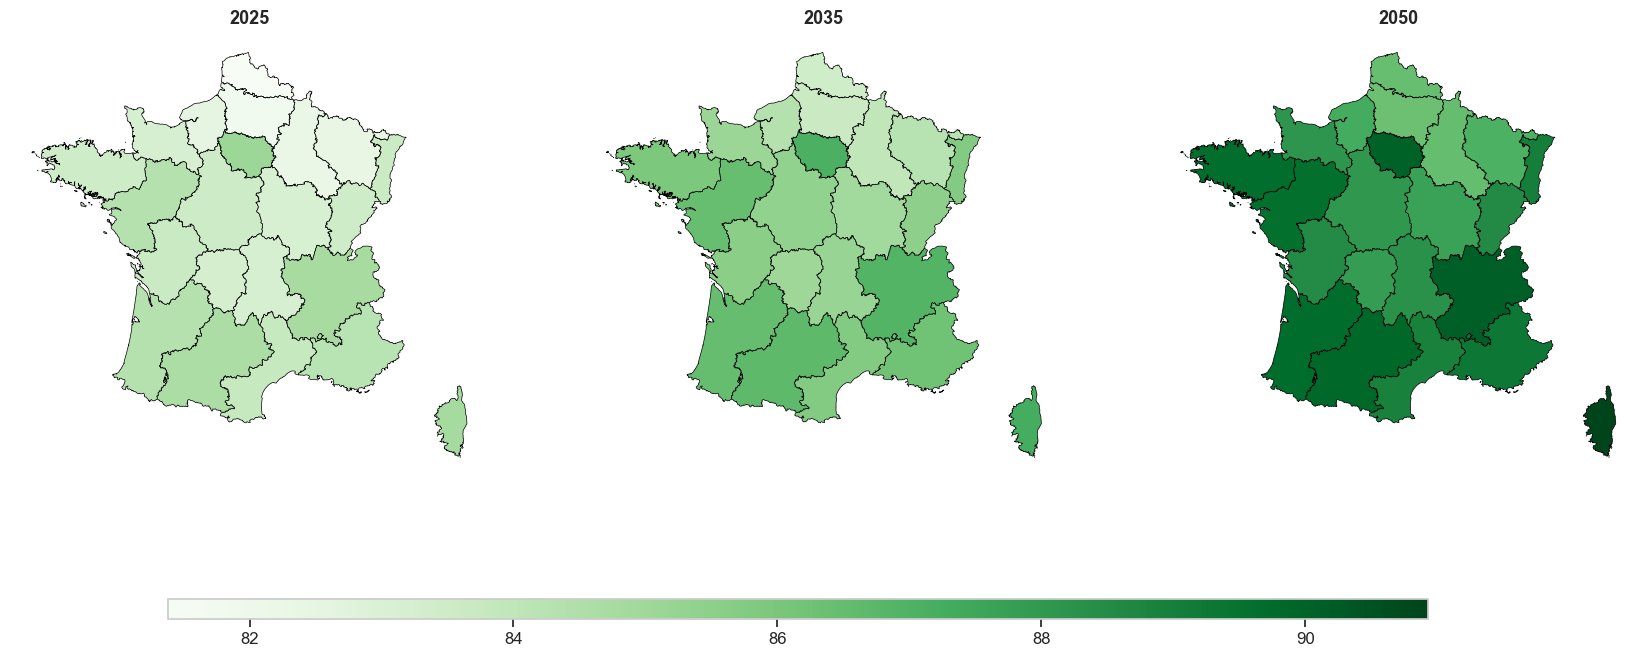

In [65]:
#Parameters
tv_future = np.arange(1990, 2023 + 28) #années
mp = MapPlotter(regions, esp_llp, tv_future, "FR", "",cmap="Greens")
#mp.plot_single_year(year=2030)
mp.plot_compare_years(years=[2025, 2035,2050])
#mp.save(path_fr + "/LifeExpectancy_at_birth_ll_parametric_color_detra.png")

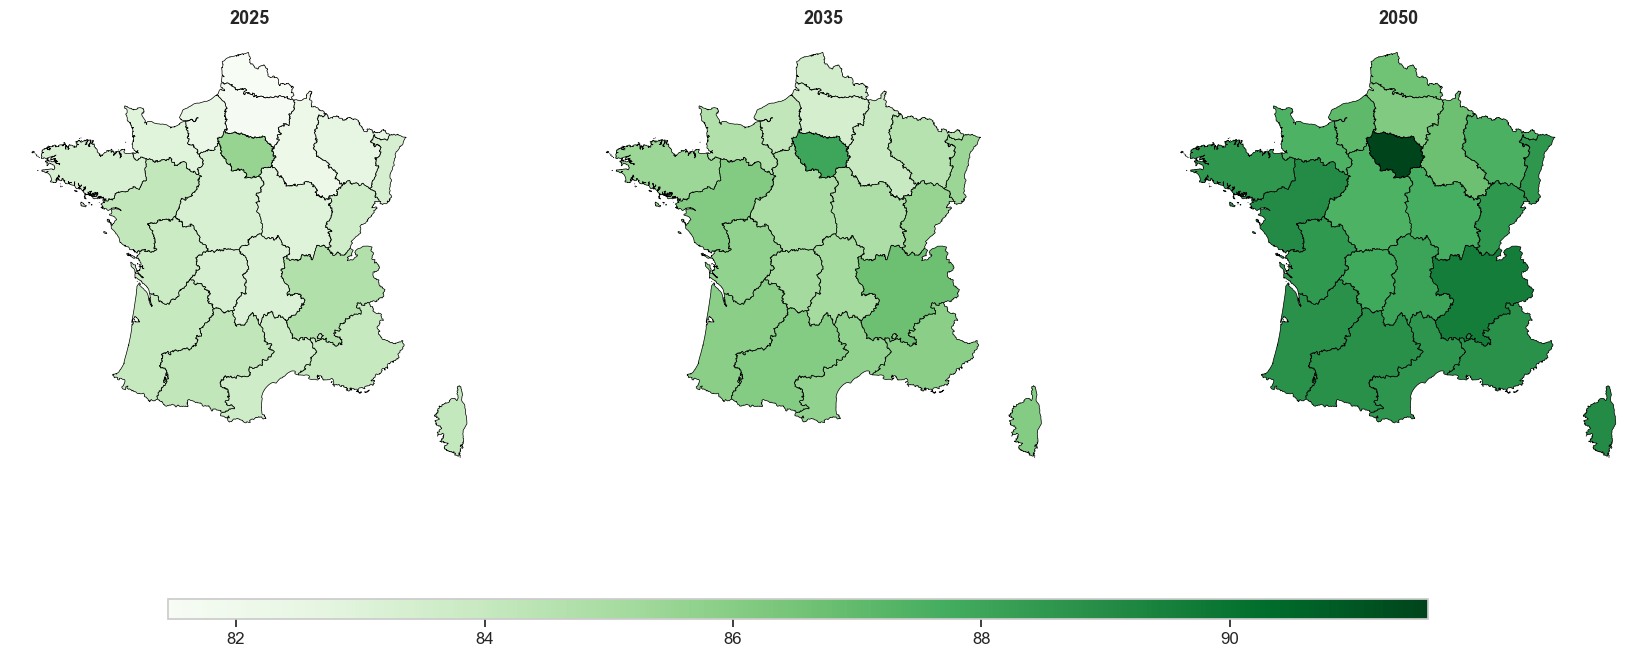

In [66]:
mp = MapPlotter(regions, esp_ll, tv_future, "FR", "",cmap="Greens")
#mp.plot_single_year(year=2030)
mp.plot_compare_years(years=[2025, 2035,2050])
#mp.save(path_fr + "/LifeExpectancy_at_birth_ll_color_detra.png")

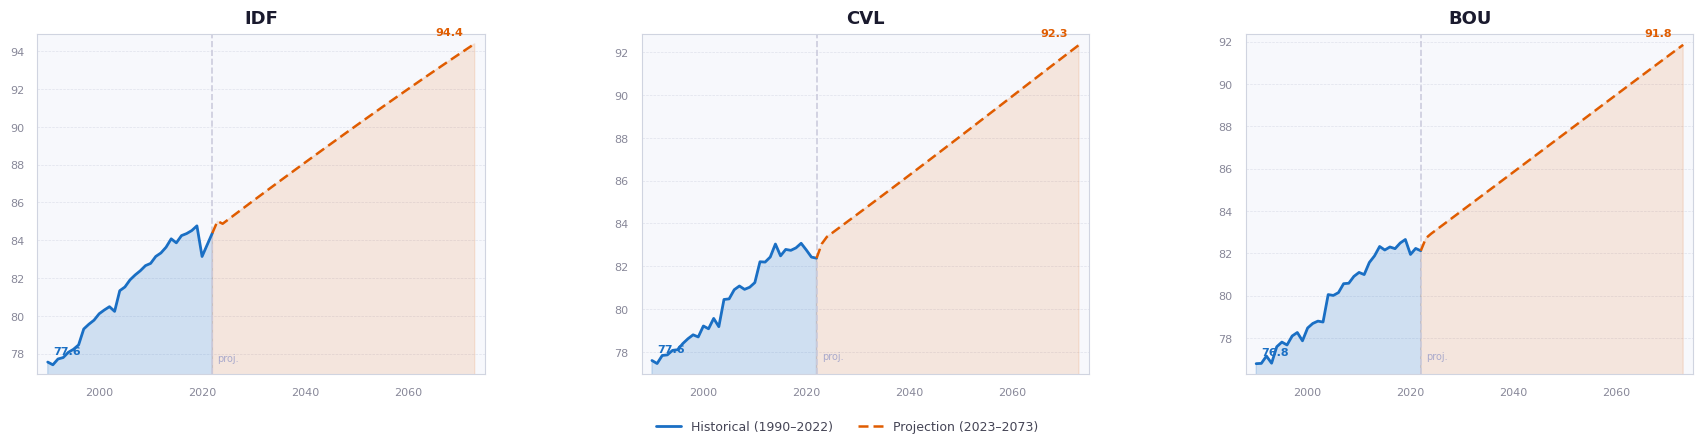

✓ Figure 1/8 sauvegardée : esperance_vie_fig01.png


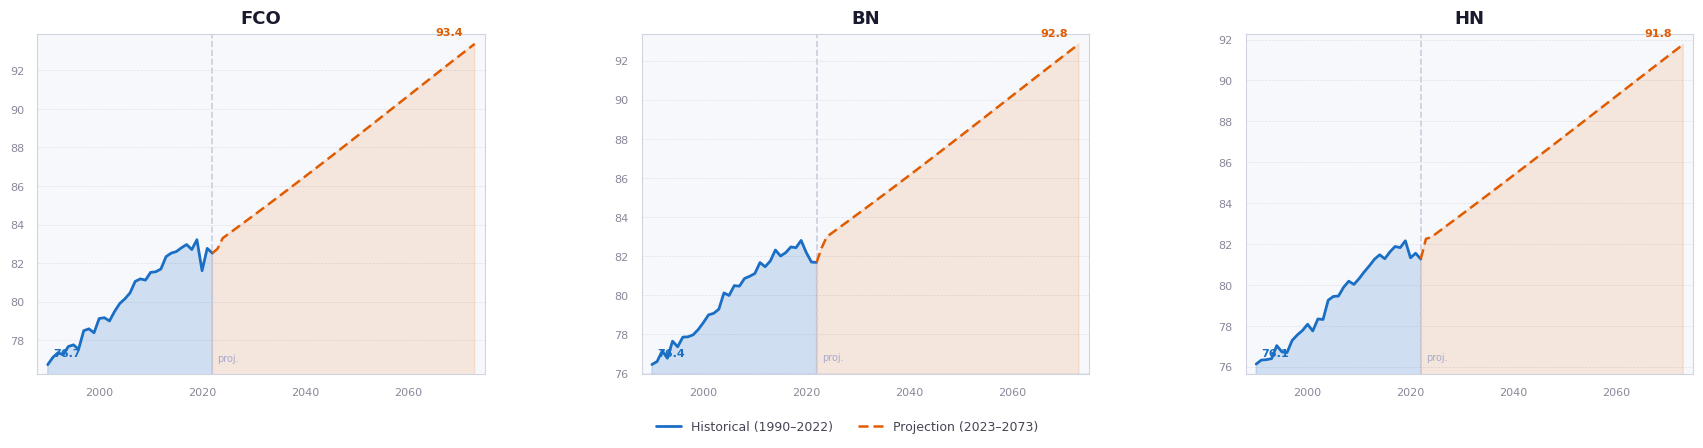

✓ Figure 2/8 sauvegardée : esperance_vie_fig02.png


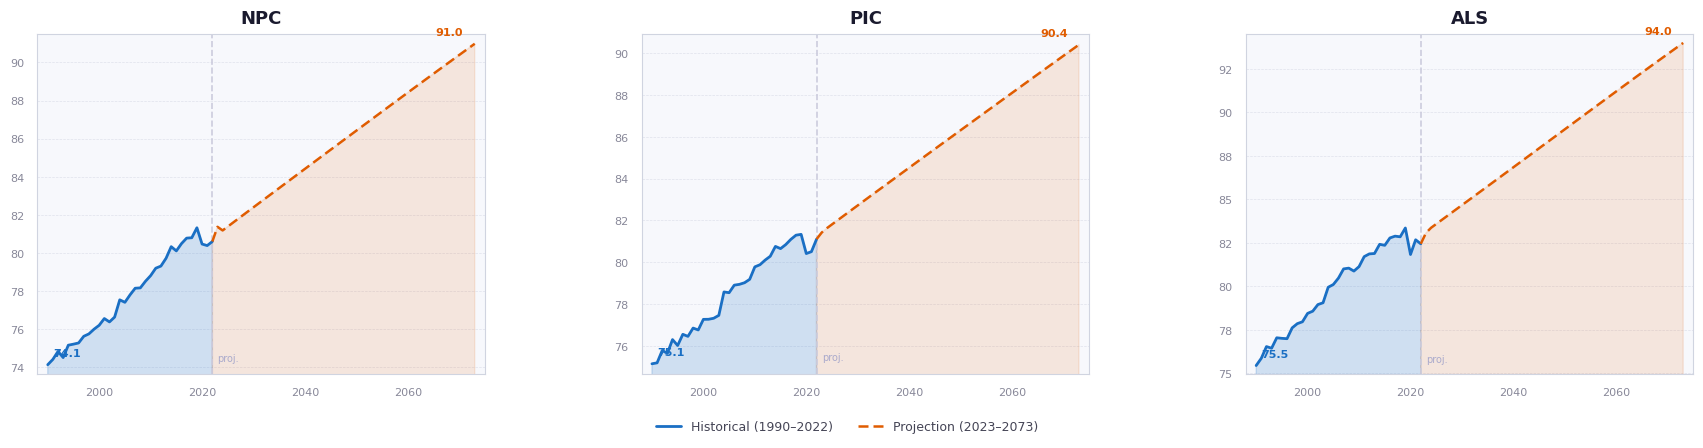

✓ Figure 3/8 sauvegardée : esperance_vie_fig03.png


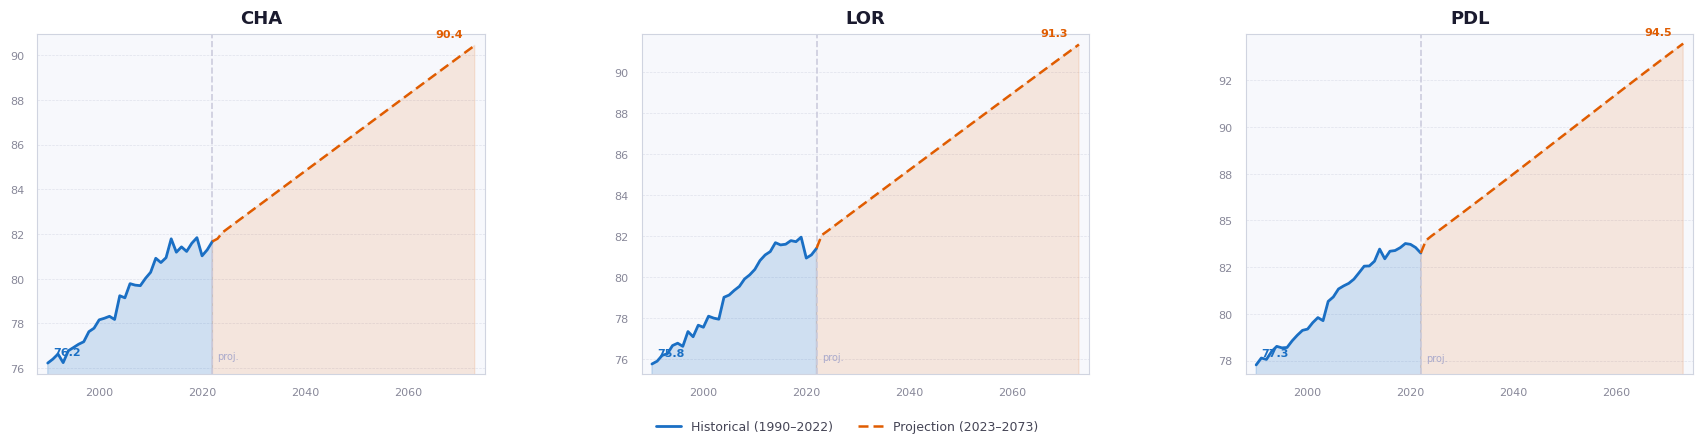

✓ Figure 4/8 sauvegardée : esperance_vie_fig04.png


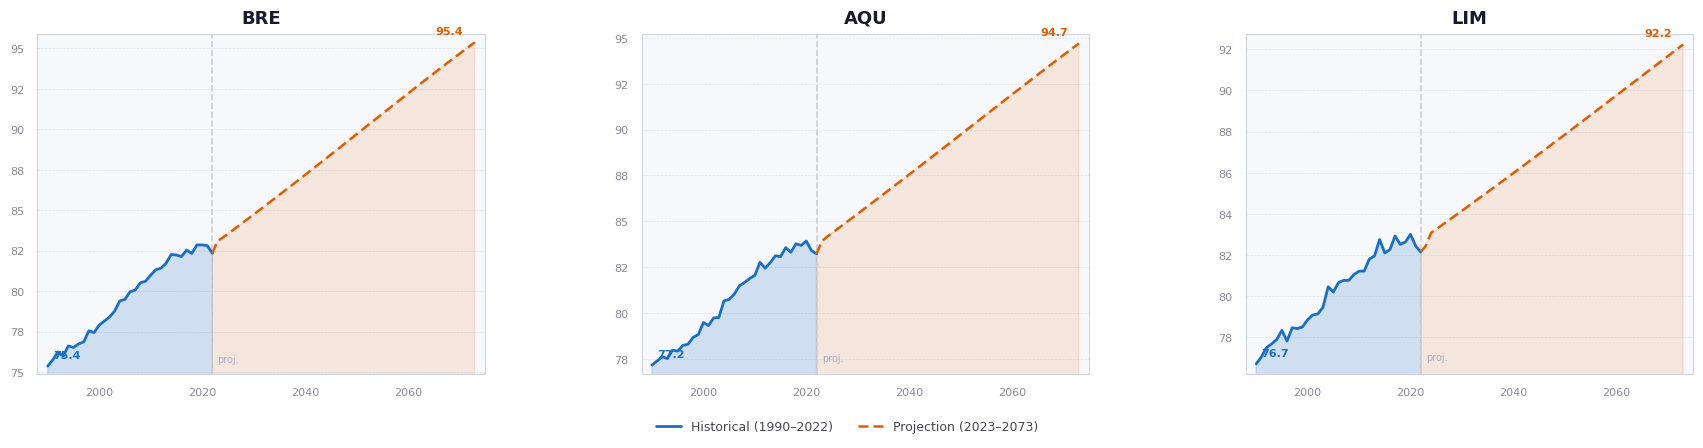

✓ Figure 5/8 sauvegardée : esperance_vie_fig05.png


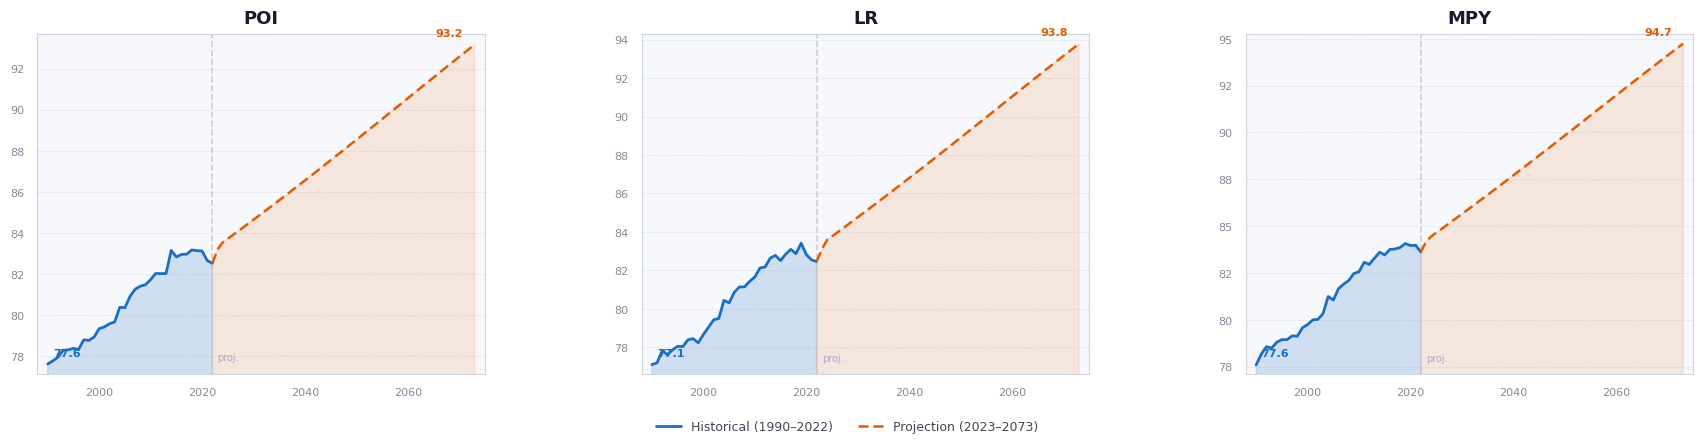

✓ Figure 6/8 sauvegardée : esperance_vie_fig06.png


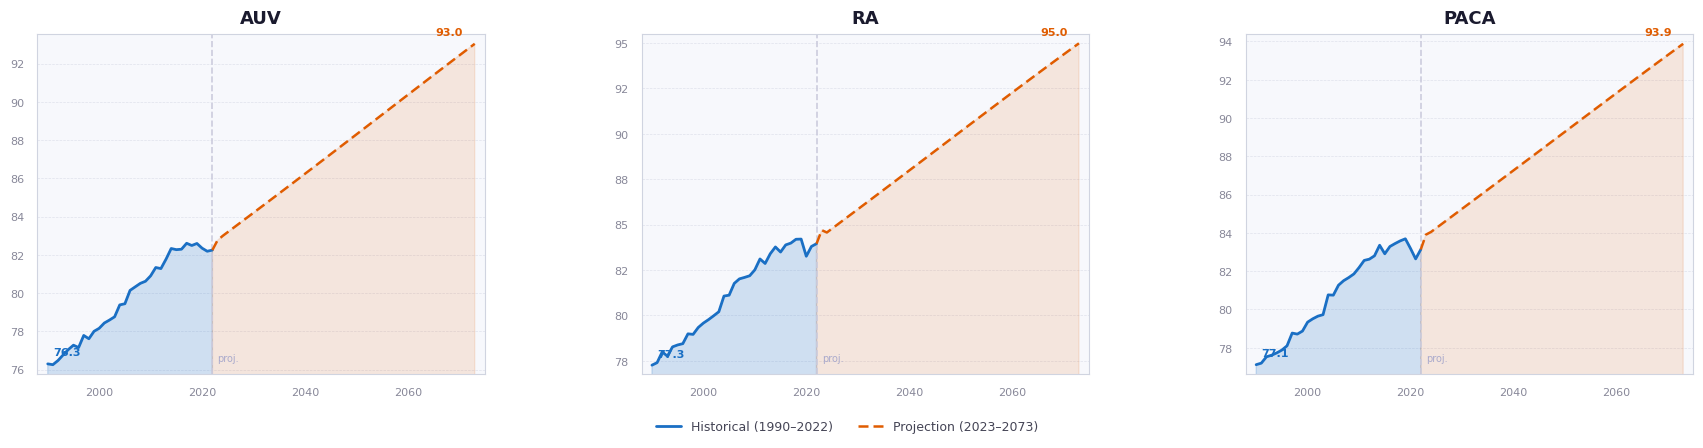

✓ Figure 7/8 sauvegardée : esperance_vie_fig07.png


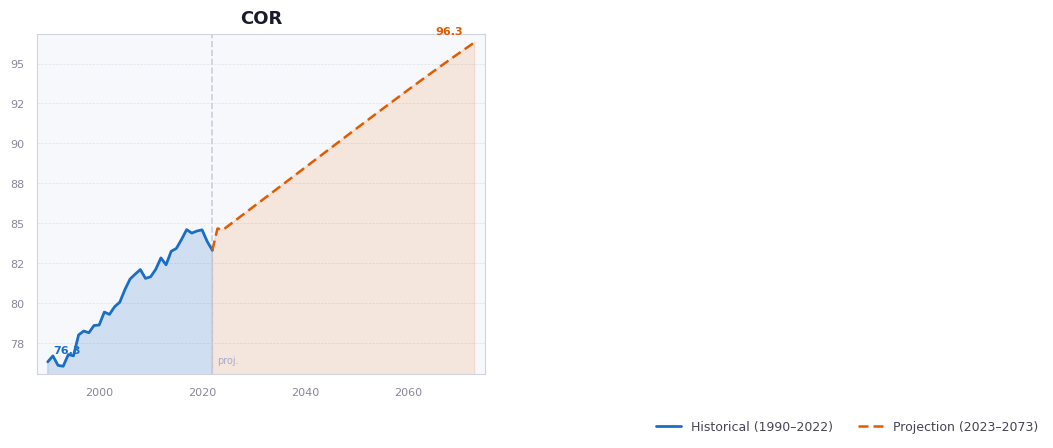

✓ Figure 8/8 sauvegardée : esperance_vie_fig08.png


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ── Palette & style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#ffffff",
    "axes.facecolor":    "#f7f8fc",
    "axes.edgecolor":    "#d0d4e0",
    "axes.labelcolor":   "#444455",
    "xtick.color":       "#888899",
    "ytick.color":       "#888899",
    "grid.color":        "#e0e2ec",
    "grid.linewidth":    0.6,
    "text.color":        "#1a1a2e",
    "font.family":       "DejaVu Sans",
})

# ── Paramètres ────────────────────────────────────────────────────────────────
HIST_LAST_YEAR = 2022   # coupure historique / projection
ACCENT = "#1a6fc4"      # bleu historique (plus foncé sur fond blanc)
PROJ   = "#e05c00"      # orange projection (plus foncé sur fond blanc)

# ── df_llp : index.name = "horizon", colonnes = régions ──────────────────────
# df_llp doit déjà être chargé dans l'environnement
# Exemple de structure :
#         BXL        ANT        LIM  ...
# horizon
# 1990    75.608374  76.072014  76.331329  ...
# 1991    75.835528  76.304287  76.654883  ...
# ...
# 2073    90.413962  92.598911  92.098857  ...

regions = df_esp_llp.columns.tolist()
years   = df_esp_llp.index.to_numpy()

# ── Groupes de 3 régions par figure ──────────────────────────────────────────
NCOLS     = 3
group_size = NCOLS  # 3 régions par figure

legend_elements = [
    Line2D([0], [0], color=ACCENT, linewidth=2,            label="Historical (1990–2022)"),
    Line2D([0], [0], color=PROJ,   linewidth=1.8,
           linestyle=(0, (4, 2)),                           label="Projection (2023–2073)"),
]

# Découpe des régions en groupes de 3
groups = [regions[i:i+group_size] for i in range(0, len(regions), group_size)]

for fig_idx, group in enumerate(groups):
    n = len(group)  # 1, 2 ou 3 selon le dernier groupe
    fig, axes = plt.subplots(1, NCOLS, figsize=(18, 5), squeeze=False)
    axes = axes.flatten()

    fig.subplots_adjust(hspace=0.4, wspace=0.35, top=0.83, bottom=0.15, left=0.05, right=0.97)

    fig.text(0.5, 0.95, "",
             ha="center", fontsize=14, fontweight="bold", color="#1a1a2e")
    fig.text(0.5, 0.89, "",
             ha="center", fontsize=9, color="#666677")

    for ax, region in zip(axes, group):
        vals_all = df_esp_llp[region].to_numpy()

        mask_h = years <= HIST_LAST_YEAR
        mask_p = years >= HIST_LAST_YEAR

        yh, vh = years[mask_h], vals_all[mask_h]
        yp, vp = years[mask_p], vals_all[mask_p]

        # Zones colorées
        ax.fill_between(yh, vh, alpha=0.18, color=ACCENT)
        ax.fill_between(yp, vp, alpha=0.12, color=PROJ)

        # Ligne de coupure
        ax.axvline(HIST_LAST_YEAR, color="#ccccdd", linewidth=1.2, linestyle="--", zorder=1)
        ax.text(HIST_LAST_YEAR + 1, vh.min() + 0.1, "proj.",
                fontsize=7, color="#aaaacc", va="bottom")

        # Courbes
        ax.plot(yh, vh, color=ACCENT, linewidth=2.0, solid_capstyle="round", zorder=3)
        ax.plot(yp, vp, color=PROJ,   linewidth=1.8, linestyle=(0, (4, 2)),
                solid_capstyle="round", zorder=3)

        # Annotations
        ax.annotate(f"{vh[0]:.1f}", xy=(yh[0], vh[0]), xytext=(4, 6),
                    textcoords="offset points", fontsize=8, color=ACCENT, fontweight="bold")
        ax.annotate(f"{vp[-1]:.1f}", xy=(yp[-1], vp[-1]), xytext=(-28, 6),
                    textcoords="offset points", fontsize=8, color=PROJ, fontweight="bold")

        # Titre
        ax.set_title(region, fontsize=13, fontweight="bold", color="#1a1a2e", pad=8)

        # Axes
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.tick_params(labelsize=8)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5)
        ax.grid(False, axis="x")
        ax.set_xlim(years.min() - 2, years.max() + 2)
        ax.set_ylim(vals_all.min() - 0.5, vals_all.max() + 0.5)

        for spine in ax.spines.values():
            spine.set_edgecolor("#d0d4e0")
            spine.set_linewidth(0.8)

    # Masquer les subplots vides du dernier groupe
    for ax in axes[n:]:
        ax.set_visible(False)

    # Légende
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
               fontsize=9, frameon=False, labelcolor="#444455",
               bbox_to_anchor=(0.5, 0.01))

    fname = f"esperance_vie_fig{fig_idx+1:02d}.png"
    plt.savefig(path_fr + fname, dpi=160, bbox_inches="tight", facecolor="#ffffff")
    plt.show()
    print(f"✓ Figure {fig_idx+1}/{len(groups)} sauvegardée : {fname}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path


def plot_life_expectancy(
    ex: np.ndarray,
    tv_hist: np.ndarray,
    tv_proj: np.ndarray,
    age_index: int = 0,
    region_names: list = None,
    regions_per_fig: int = 3,
    ci_lower: np.ndarray = None,
    ci_upper: np.ndarray = None,
    save_path: str = None,
    dpi: int = 150,
):
    """
    Plot the evolution of life expectancy by region (historical + projected).

    Generates one figure per group of ``regions_per_fig`` regions.
    Historical data (1990–2022) is drawn as a solid line; projected years
    are drawn as a dashed line with an optional shaded confidence interval.

    Parameters
    ----------
    ex : np.ndarray, shape (nb_ages, nb_years, nb_regions)
        Life expectancy array.  The full time axis is
        ``np.concatenate([tv_hist, tv_proj])``.
    tv_hist : np.ndarray
        Historical year vector (e.g. 1990–2022, length 33).
    tv_proj : np.ndarray
        Projected year vector (e.g. 2023–2072).
    age_index : int
        Age slice to plot (0 = e₀, 65 = e₆₅, …). Default: 0.
    region_names : list of str, optional
        Labels for each region.  Defaults to ["Region 1", "Region 2", …].
    regions_per_fig : int
        Number of regions per figure (= subplot columns).  Default: 3.
    ci_lower : np.ndarray, shape (nb_proj_years, nb_regions), optional
        Lower bound of the confidence interval for the projected period.
    ci_upper : np.ndarray, shape (nb_proj_years, nb_regions), optional
        Upper bound of the confidence interval for the projected period.
    save_path : str or Path, optional
        Base path for saving figures.  Each figure is saved with a
        ``_part{i}`` suffix before the extension.
        Example: ``"output/ex.png"``  →  ``"output/ex_part1.png"``, …
        The parent directory is created automatically if it does not exist.
    dpi : int
        Resolution used when saving (default: 150).

    Returns
    -------
    figs : list of matplotlib.figure.Figure
        One figure per group of regions.
    """

    tv_hist = np.asarray(tv_hist)
    tv_proj = np.asarray(tv_proj)
    tv_all  = np.concatenate([tv_hist, tv_proj])

    nb_ages, nb_years, nb_regions = ex.shape
    n_hist = len(tv_hist)   # number of historical years
    n_proj = len(tv_proj)   # number of projected years

    if region_names is None:
        region_names = [f"Region {g + 1}" for g in range(nb_regions)]

    # Extract the chosen age slice → shape (nb_years, nb_regions)
    ex_age = ex[age_index, :, :]

    # Split into historical and projected blocks
    ex_hist = ex_age[:n_hist, :]          # (n_hist, nb_regions)
    ex_proj = ex_age[n_hist:, :]          # (n_proj, nb_regions)

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    n_figs = int(np.ceil(nb_regions / regions_per_fig))
    figs   = []

    # Label displayed in the y-axis
    age_label = "e₀" if age_index == 0 else f"e{age_index}"

    for f in range(n_figs):
        g_start = f * regions_per_fig
        g_end   = min(g_start + regions_per_fig, nb_regions)
        group   = list(range(g_start, g_end))
        ncols   = len(group)

        fig, axes = plt.subplots(
            1, ncols,
            figsize=(5 * ncols, 4),
            sharey=False,
        )
        axes = np.array(axes).reshape(-1)

        for pos, g in enumerate(group):
            ax    = axes[pos]
            color = colors[g % len(colors)]

            # ── Historical curve (solid line) ────────────────────────
            ax.plot(
                tv_hist,
                ex_hist[:, g],
                color=color,
                lw=2.0,
                label="Historical",
            )

            # ── Bridge point connecting historical to projected ──────
            bridge_x = np.concatenate([[tv_hist[-1]], tv_proj])
            bridge_y = np.concatenate([[ex_hist[-1, g]], ex_proj[:, g]])

            # ── Confidence interval (shaded band) ───────────────────
            if ci_lower is not None and ci_upper is not None:
                lo_bridge = np.concatenate([[ex_hist[-1, g]], ci_lower[:, g]])
                hi_bridge = np.concatenate([[ex_hist[-1, g]], ci_upper[:, g]])
                ax.fill_between(
                    bridge_x,
                    lo_bridge,
                    hi_bridge,
                    color=color,
                    alpha=0.18,
                    label="95% CI",
                )

            # ── Projected curve (dashed line) ────────────────────────
            ax.plot(
                bridge_x,
                bridge_y,
                color=color,
                lw=2.0,
                label="Projected",
            )

            # ── Vertical separator between history and projection ────
            ax.axvline(tv_hist[-1], color="grey", lw=0.8, linestyle=":")
            ax.text(
                tv_hist[-1] + 0.5,
                ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else ex_hist[:, g].min() * 0.995,
                "proj.",
                fontsize=7,
                color="grey",
                va="bottom",
            )

            # ── Styling ──────────────────────────────────────────────
            ax.set_title(region_names[g], fontsize=11, fontweight="bold")
            ax.set_xlabel("Year", fontsize=9)
            ax.set_ylabel(f"Life expectancy {age_label} (years)", fontsize=9)
            ax.legend(fontsize=7, loc="best")
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=8)

        fig.suptitle(
            f"Life expectancy {age_label} by region",
            fontsize=12,
            fontweight="bold",
            y=1.01,
        )
        fig.tight_layout()
        figs.append(fig)

        # # ── Save ─────────────────────────────────────────────────────
        # if save_path is not None:
        #     p = Path(save_path)
        #     p.parent.mkdir(parents=True, exist_ok=True)
        #     out = p.parent / f"{p.stem}_part{f + 1}{p.suffix}"
        #     fig.savefig(out, dpi=dpi, bbox_inches="tight")
        #     print(f"✅ Saved → {out}")

    plt.show()
    return figs




# ════════════════════════════════════════════════════════════════════
# USAGE EXAMPLE
# ════════════════════════════════════════════════════════════════════

# ex       : shape (111, 84, 22)  → (nb_ages, nb_years, nb_regions)
# tv_hist  : np.arange(1990, 2023)   → 33 years
# tv_proj  : np.arange(2023, 2074)   → 51 projected years
# (total nb_years = 33 + 51 = 84)

# ── Simple plot (e₀, no CI) ─────────────────────────────────────────
# figs = plot_life_expectancy(
#     ex        = ex,
#     tv_hist   = np.arange(1990, 2023),
#     tv_proj   = np.arange(2023, 2074),
#     age_index = 0,
# )

# ── With confidence interval ────────────────────────────────────────
# figs = plot_life_expectancy(
#     ex           = ex,
#     tv_hist      = np.arange(1990, 2023),
#     tv_proj      = np.arange(2023, 2074),
#     age_index    = 0,
#     ci_lower     = ex_lower,     # shape (51, 22)
#     ci_upper     = ex_upper,     # shape (51, 22)
#     region_names = region_list,
#     save_path    = "output/life_expectancy_e0.png",
# )

# ── Plot e₆₅ instead of e₀ ─────────────────────────────────────────
# figs = plot_life_expectancy(
#     ex        = ex,
#     tv_hist   = np.arange(1990, 2023),
#     tv_proj   = np.arange(2023, 2074),
#     age_index = 65,
# )

C:\Users\Idrissa Belem\AppData\Local\Temp\ipykernel_11660\3738820307.py:161: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


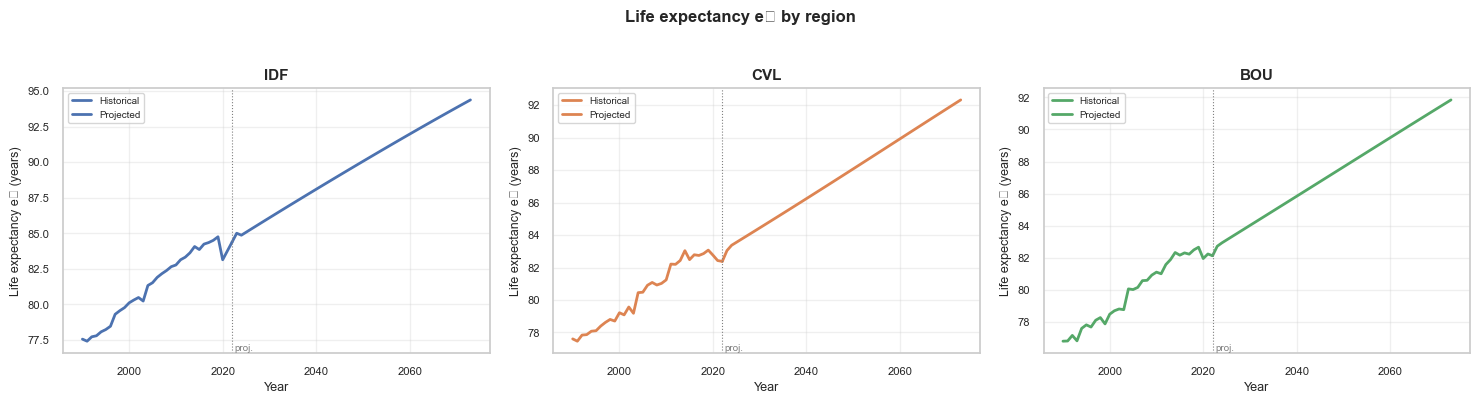

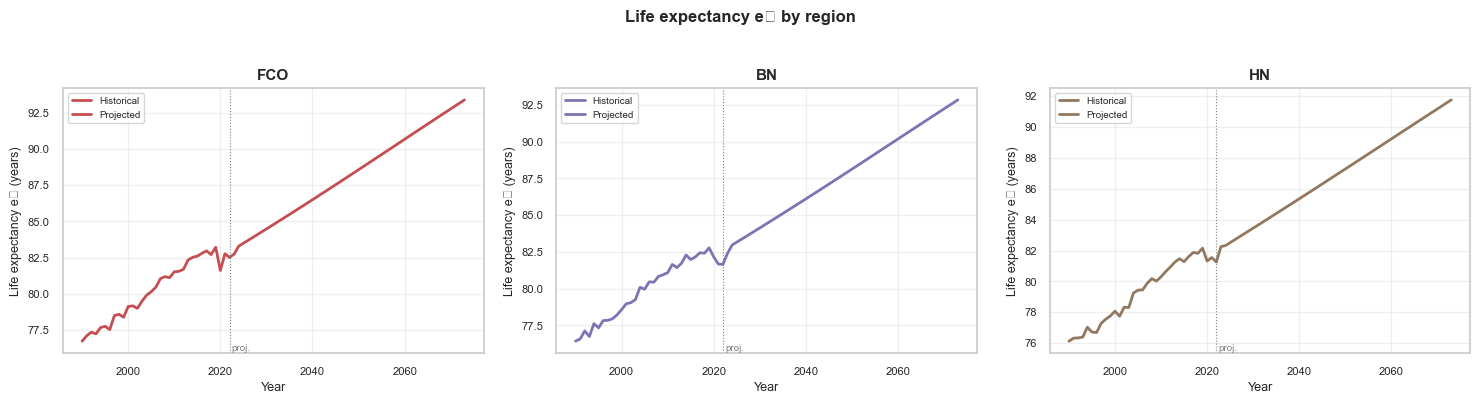

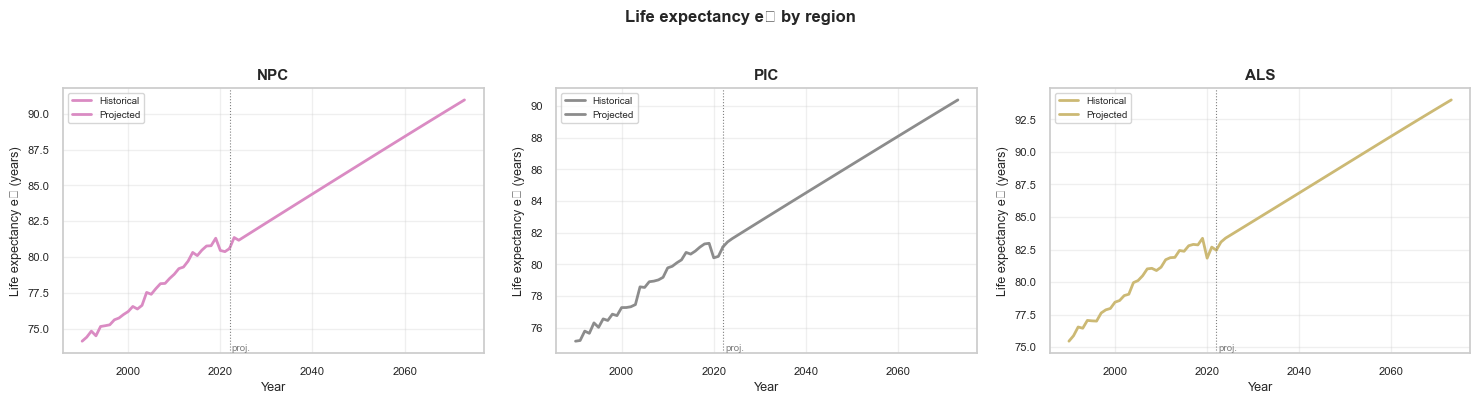

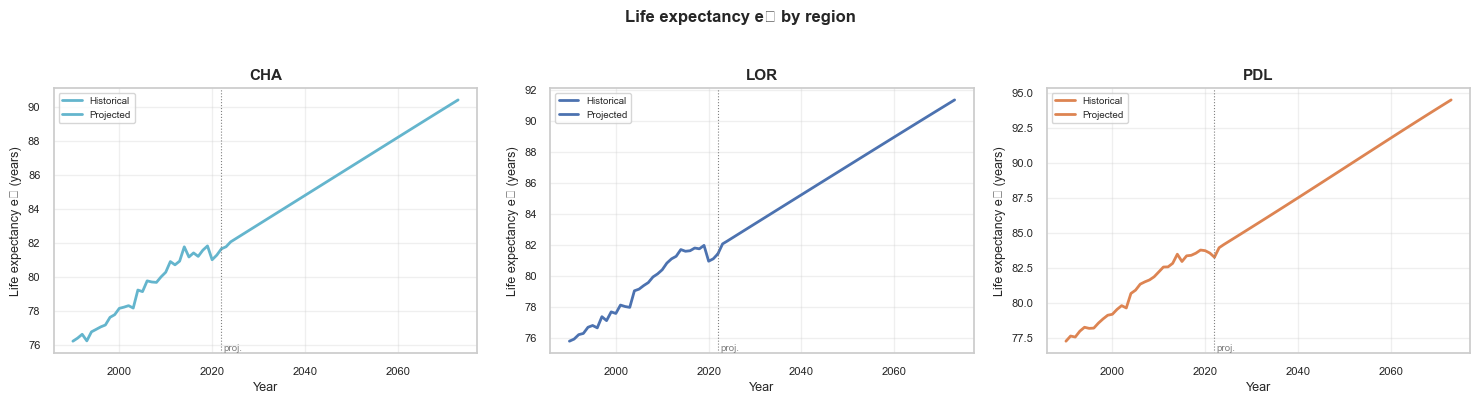

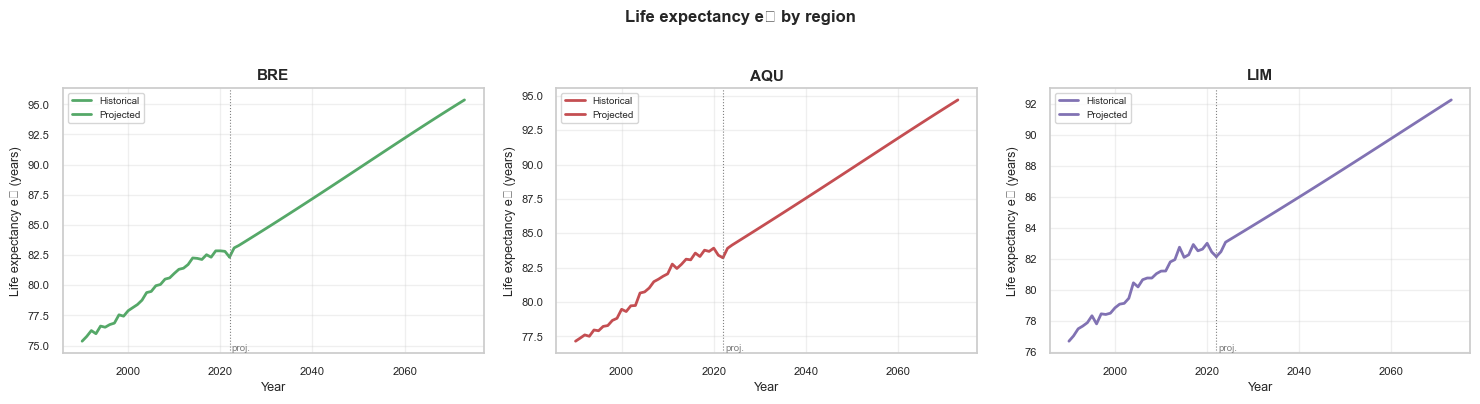

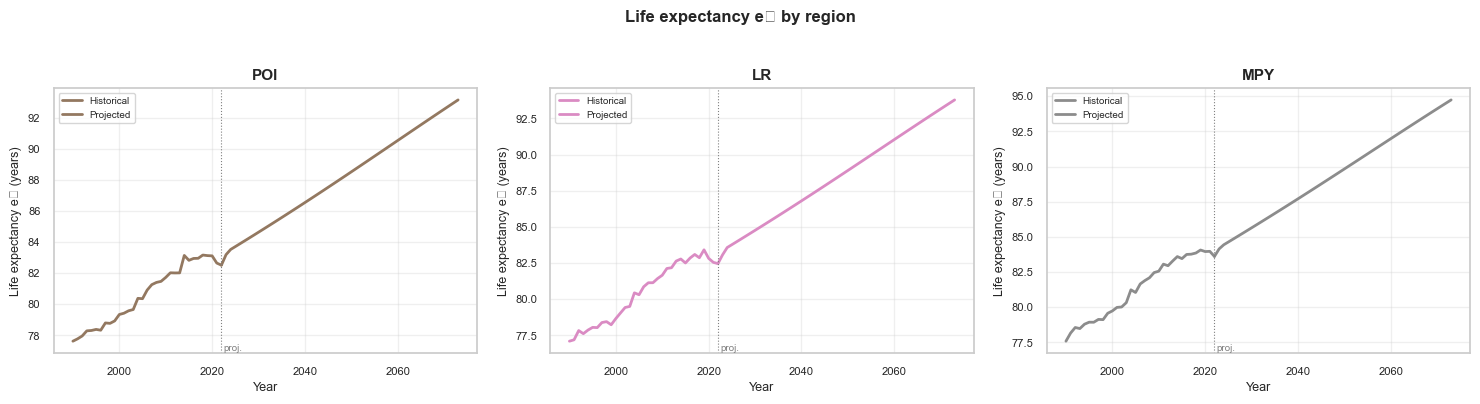

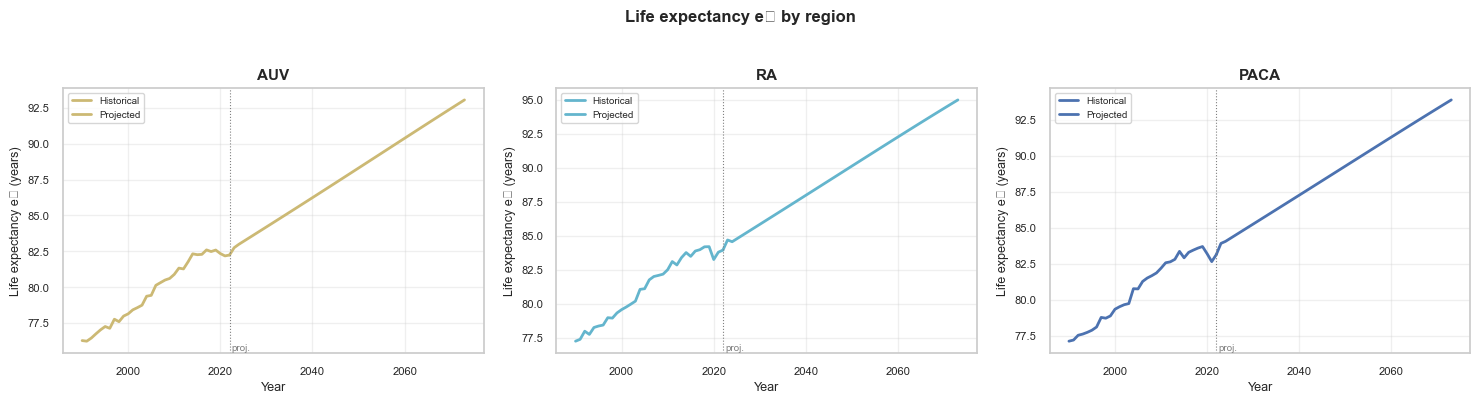

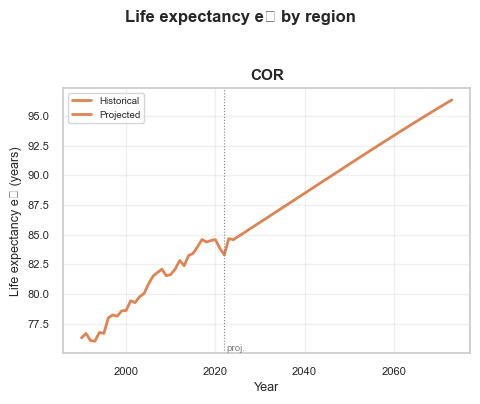

In [79]:

tv_hist  : np.arange(1990, 2023)   #→ 33 years
tv_proj  : np.arange(2023, 2074)   #→ 51 projected years

#── Simple plot (e₀, no CI) ─────────────────────────────────────────
figs = plot_life_expectancy(
    ex        = esp_llp,
    tv_hist   = np.arange(1990, 2023),
    tv_proj   = np.arange(2023, 2074),
    age_index = 0,
    region_names=region_labels
)

#### Annuity_pricing

In [395]:
# xe = np.array([60])  # âge de souscription

# price_national = Annuity_pricing(
#     xe       = xe,
#     xv       = xv,
#     log_Muxtg = logmu_nation_lcp,  # (nb_ages, horizon, nb_reg, nb_simul)
#     duration  = 20,
#     rate      = 0.02   # taux d'actualisation à adapter
# )

# print("price shape:", price_national.shape)  # (1, nb_reg, nb_simul)

In [396]:
# price_multi = Annuity_pricing(
#     xe       = xe,
#     xv       = xv,
#     log_Muxtg = logmu_extrap_lcp,  # (nb_ages, horizon, nb_reg, nb_simul)
#     duration  = 20,
#     rate      = 0.02   # taux d'actualisation à adapter
# )

# print("price shape:", price_multi.shape)  # (1, nb_reg, nb_simul)

In [397]:
# France_nuts2 = {
#     "FR10": "IDF",        # Île-de-France
#     "FRB0": "CVL",        # Centre-Val de Loire
#     "FRC1": "BOU",        # Bourgogne
#     "FRC2": "FCO",        # Franche-Comté
#     "FRD1": "BN",         # Basse-Normandie
#     "FRD2": "HN",         # Haute-Normandie
#     "FRE1": "NPC",        # Nord-Pas de Calais
#     "FRE2": "PIC",        # Picardie
#     "FRF1": "ALS",        # Alsace
#     "FRF2": "CHA",        # Champagne-Ardenne
#     "FRF3": "LOR",        # Lorraine
#     "FRG0": "PDL",        # Pays de la Loire
#     "FRH0": "BRE",        # Bretagne
#     "FRI1": "AQU",        # Aquitaine
#     "FRI2": "LIM",        # Limousin
#     "FRI3": "POI",        # Poitou-Charentes
#     "FRJ1": "LR",         # Languedoc-Roussillon
#     "FRJ2": "MPY",        # Midi-Pyrénées
#     "FRK1": "AUV",        # Auvergne
#     "FRK2": "RA",         # Rhône-Alpes
#     "FRL0": "PACA",       # Provence-Alpes-Côte d’Azur
#     "FRM0": "COR"         # Corse
# }


# region_labels = [France_nuts2.get(r, r) for r in regions]

In [398]:
# # Cas 1 – régions seules
# AnnuityBoxPlotter(price_multi, region_labels).plot()

  

In [ ]:
# # ── AnnuityBoxPlotter — one extra series ───────────────────────────
# AnnuityBoxPlotter(price_multi, region_labels, extra_series=[
#     ExtraSeries(price_national, "LC", position="last"),
# ]).plot()


: 

In [ ]:
# lcp_mean = np.mean(esp_lcp,axis=3)
# llp_mean = np.mean(esp_llp,axis=3)

: 

### Annexes

In [62]:
# shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
# stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
# mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
# Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
# Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)

In [ ]:

# #Construction base spline pour connaître n_basis
# B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

# ax_coef_init = np.zeros(n_basis)
# bx_coef_init = np.ones((len(regions), n_basis))
# kappa_init =  np.ones(len(tv))

# model_multi = LiLee.Parametric.LeeAndLi(
#     degree=degree,
#     n_knots=n_knots,
#     lam=lam,
#     nb_iter=5000,
#     eta0=0.2,
#     tol=1e-3,
#     verbose=True,
# )

# result_llp = model_multi.fit(
#     ax_coef_init  = ax_coef_init,
#     bx_coef_init  = bx_coef_init,
#     kappa_init    = kappa_init,
#     Extg          = Extg,
#     Dxtg          = Dxtg,
#     xv            = xv,
#     tv            = tv,)

: 

In [ ]:
# # Juste après init_params, avant le fit
# alpha_coef, beta_coef, beta_g_coef, kappa_common, kappa_g = model_p.init_params(Dxtg, Extg, xv)

# print("kappa_g NaN :", np.isnan(kappa_g).any())
# print("beta_g_coef NaN :", np.isnan(beta_g_coef).any())
# print("kappa_common NaN :", np.isnan(kappa_common).any())

# # Drifts kappa_g après init
# diffs = np.diff(kappa_g, axis=1)
# drift = diffs.mean(axis=1)
# for g, name in enumerate(regions):
#     print(f"{name}: drift = {drift[g]:.4f}")

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# mae_regional = {
#     "Li and Lee variant": mae_ll['wmae_by_region'],  # (nb_regions,)
#     "Li and Lee":         mae_llp['wmae_by_region'],          # (nb_regions,)
# }

# mae_national = {
#     "National model": mae_lcp['wmae_global'],  # scalaire
# }

# France_nuts2 = {
#     "FR10": "IDF", "FRB0": "CVL", "FRC1": "BOU", "FRC2": "FCO",
#     "FRD1": "BN",  "FRD2": "HN",  "FRE1": "NPC", "FRE2": "PIC",
#     "FRF1": "ALS", "FRF2": "CHA", "FRF3": "LOR", "FRG0": "PDL",
#     "FRH0": "BRE", "FRI1": "AQU", "FRI2": "LIM", "FRI3": "POI",
#     "FRJ1": "LR",  "FRJ2": "MPY", "FRK1": "AUV", "FRK2": "RA",
#     "FRL0": "PACA","FRM0": "COR"
# }
# region_labels = list(France_nuts2.values())

# all_models  = list(mae_regional.keys()) + list(mae_national.keys())
# n_models    = len(all_models)
# colors      = ["#1f77b4", "#ff7f0e", "#2ca02c"]
# width       = 0.8 / n_models
# n           = len(region_labels)
# x           = np.arange(n + 1)  # +1 pour la colonne nationale

# fig, ax = plt.subplots(figsize=(15, 5))

# # --- Barres régionales ---
# for i, (model, color) in enumerate(zip(mae_regional.keys(), colors)):
#     offset = (i - n_models / 2 + 0.5) * width
#     ax.bar(x[:n] + offset, mae_regional[model], width, label=model, color=color)

# # --- Barre nationale (même width, même style) ---
# for i, (model, value) in enumerate(mae_national.items()):
#     model_idx = len(mae_regional) + i
#     offset = (model_idx - n_models / 2 + 0.5) * width
#     ax.bar(x[-1] + offset, value, width, label=f"{model}", color=colors[model_idx])

# # Ligne verticale de séparation
# ax.axvline(n - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

# xtick_labels = region_labels + ["National"]
# ax.set_xticks(x)
# ax.set_xticklabels(xtick_labels, rotation=0, fontsize=8)
# ax.set_xlabel("Région")
# ax.set_ylabel("WMAE")
# ax.legend()
# ax.grid(axis="y", alpha=0.3)

# plt.tight_layout()
# plt.show()